# [초급 프로젝트] 4팀_김명환 - 데이타 전처리

---
---

# 경구약제 이미지 데이터 EDA

In [45]:
# 기본 라이브러리

# --- Scikit-learn: 데이터 전처리, 모델, 평가 ---
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import (
    fetch_california_housing, load_iris, make_moons, make_circles,
    load_breast_cancer, load_wine
)
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.metrics import average_precision_score

# --- 기타 라이브러리 ---
import cv2
from PIL import Image
from PIL import ImageFilter
from PIL import ImageDraw
import albumentations as A
import IPython.display
#from tqdm import tqdm
from tqdm.notebook import tqdm

# --- PyTorch: 딥러닝 관련 ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torch.utils.data import Subset
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as TF
from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset
from collections import OrderedDict
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

# --- 기타 ---
import re
import os
import sys
import copy
import json
import math
import random
import yaml
import shutil
import pandas as pd
import numpy as np
import seaborn as sns
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from datetime import datetime
from datetime import timezone, timedelta
import pytz
__kst = pytz.timezone('Asia/Seoul')

# GPU 설정
__device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
__device_cpu = torch.device('cpu')

  # 재현 가능한 결과를 위해
np.random.seed(42)
torch.manual_seed(42)
if __device == 'cuda':
    torch.cuda.manual_seed_all(42)

print(f"라이브러리 로드 완료 사용장치:{__device}")

라이브러리 로드 완료 사용장치:cpu


In [46]:
from urllib.request import urlretrieve; urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_c0z0c_dev.py", "helper_c0z0c_dev.py")
import importlib
import helper_c0z0c_dev as helper
importlib.reload(helper)

🌐 https://c0z0c.github.io/jupyter_hangul
ℹ️ NumPy 2.1.3 (v2.x+): 호환성 모드 적용됨
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = d:\GoogleDrive\codeit_ai_health_eat\scripts\김명환


<module 'helper_c0z0c_dev' from 'd:\\GoogleDrive\\codeit_ai_health_eat\\scripts\\김명환\\helper_c0z0c_dev.py'>

In [ ]:
# OS 및 경로 관련 라이브러리 임포트
import os, sys
from pathlib import Path

try:
    import google.colab
    from google.colab import drive
    COLAB_AVAILABLE = True
except ImportError:
    COLAB_AVAILABLE = False

# 유틸리티 함수 디렉토리 경로 설정 (Colab 환경 여부에 따라 다르게 지정)
utils_dir = None
if COLAB_AVAILABLE:
    # Colab 환경일 경우 Google Drive 경로 사용
    utils_dir = "/content/drive/MyDrive/codeit_ai_health_eat/src/python_modules/utils"
else:
    # 로컬 환경일 경우 현재 드라이브 기준 경로 사용
    utils_dir = os.path.join(Path.cwd().drive + '\\\\', 'GoogleDrive', "codeit_ai_health_eat", "src", "python_modules", "utils")

print("utils_dir:", utils_dir)

# 유틸리티 함수 경로를 파이썬 모듈 검색 경로에 추가
sys.path.append(str(utils_dir))
print("sys.path:", sys.path)

# health_ea_utils 모듈 임포트 및 최신화(reload)
import importlib
import health_ea_utils as heu
importlib.reload(heu)
from health_ea_utils import *

# helper 및 health_ea_utils 파일 경로 출력 (디버깅용)
print("helper.__file__:", helper.__file__)
print("health_ea_utils.__file__:", heu.__file__)

utils_dir: d:\\GoogleDrive\codeit_ai_health_eat\src\python_modules\utils
sys.path: ['c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\python310.zip', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\DLLs', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827', '', 'C:\\Users\\sw1\\AppData\\Roaming\\Python\\Python310\\site-packages', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib\\site-packages', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib\\site-packages\\win32', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib\\site-packages\\win32\\lib', 'c:\\Users\\sw1\\anaconda3\\envs\\env_colab_250827\\lib\\site-packages\\Pythonwin', 'd:\\\\GoogleDrive\\codeit_ai_health_eat\\src\\python_modules\\utils', 'd:\\GoogleDrive\\codeit_ai_health_eat\\src\\python_modules\\utils', 'd:\\GoogleDrive\\codeit_ai_health_eat\\src\\python_modules\\utils', 'd:\\\\GoogleDrive\\codeit_ai_health_eat\\src\\python_modules\\utils']
🌐 

In [48]:
def get_tqdm_kwargs():
    """Widget 오류를 방지하는 안전한 tqdm 설정"""
    return {
        'disable': False,
        'leave': True,
        'file': sys.stdout,
        'ascii': True,  # ASCII 문자만 사용
        'dynamic_ncols': False,
#        'ncols': 80  # 고정 폭
    }

def drive_root():
    """
    Google Drive의 최상위 경로를 반환하는 함수입니다.
    - 로컬 환경(Windows): D:\GoogleDrive
    - Colab 환경: /content/drive/MyDrive
    프로젝트 내에서 데이터, 모델, 설정 파일 등 경로를 일관되게 관리할 때 사용합니다.
    """    
    root_path = os.path.join(Path.cwd().drive + '\\', "GoogleDrive")
    if helper.is_colab:
        root_path = os.path.join("/content/drive/MyDrive")
    return root_path

def get_path_modeling(add_path = None):
    """
    get_path_modeling() 함수는 모델링 관련 파일(예: 학습 결과, 체크포인트, 로그 등)을 저장할 경로를 반환합니다.
    기본적으로 Google Drive의 루트 경로(drive_root()) 아래 "modeling_yolo" 폴더를 기준으로 경로를 생성합니다.
    추가 하위 경로가 필요할 경우 add_path 인자를 통해 세부 폴더까지 지정할 수 있습니다.
    예시:
    get_path_modeling() → modeling_yolo (로컬)
    get_path_modeling("exp1") → D:\GoogleDrive\modeling_yolo\exp1
    Colab 환경에서는 /content/drive/MyDrive/modeling_yolo로 반환됩니다.
    """
    
    modeling_path = "modeling_yolo"
    path = os.path.join(drive_root(),modeling_path)
    if add_path is not None:
        path = os.path.join(path,add_path)
    return path

def get_path_modeling_release(add_path = None):
    """
    get_path_modeling_release() 함수는 모델링 결과물(예: 학습 결과, 체크포인트, 로그 등)을 저장할 경로를 반환합니다.
    기본적으로 Google Drive의 루트 경로(drive_root()) 아래 "modeling_yolo" 폴더를 기준으로 경로를 생성합니다.
    추가 하위 경로가 필요할 경우 add_path 인자를 통해 세부 폴더까지 지정할 수 있습니다.
    예시:
    get_path_modeling_release() → modeling_yolo (로컬)
    get_path_modeling_release("exp1") → D:\GoogleDrive\modeling_yolo\exp1
    Colab 환경에서는 /content/drive/MyDrive/modeling_yolo로 반환됩니다._
    """
    modeling_path = "modeling_yolo"
    path = os.path.join(drive_root(),modeling_path)
    if add_path is not None:
        path = os.path.join(path,add_path)
    return path

def print_dir_tree(root, max_depth=2, list_count=3, indent=""):
    """
    지정한 폴더(root) 하위의 디렉토리 구조를 트리 형태로 출력하는 함수입니다.

    Args:
        root: 시작 경로(폴더)
        max_depth: 출력할 최대 깊이(디폴트 2)
        list_count: 파일 개수가 많을 때 몇 개만 출력할지(디폴트 3)
        indent: 들여쓰기(재귀적으로 사용)
    """
    import os
    if max_depth < 0:
        return
    try:
        items = os.listdir(root)
    except Exception as e:
        print(indent + f"[Error] {e}")
        return

    img_count = len([f for f in os.listdir(root) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.xml', '.inf', '.txt'))])
    for item in items:
        path = os.path.join(root, item)
        if os.path.isdir(path):
            print(indent + "|-- "+ item)
            # 이미지 파일 개수만 출력
            img_count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.xml', '.inf', '.txt'))])
            if img_count > list_count:
                print(indent + "   "+ f"[데이터파일: {img_count}개]")
            print_dir_tree(root=path, max_depth=max_depth-1, list_count=list_count, indent=indent + "   ")
        else:
            if list_count < img_count and item.lower().endswith(('.jpg', '.jpeg', '.png', '.xml', '.inf', '.txt')):
                continue
            print(indent + "|-- "+ item)

def save_model_dict(model, path, pth_name, kwargs=None):
    """모델 state_dict와 추가 정보를 저장"""
    def safe_makedirs(path):
        """안전한 디렉토리 생성"""
        if os.path.exists(path) and not os.path.isdir(path):
            os.remove(path)  # 파일이면 삭제
        os.makedirs(path, exist_ok=True)

    # 디렉토리 생성
    safe_makedirs(path)

    # 모델 구조 정보 추출
    model_info = {
        'class_name': model.__class__.__name__,
        'init_args': {},
        'str': str(model),
        'repr': repr(model),
        'modules': [m.__class__.__name__ for m in model.modules()],
    }

    # 생성자 인자 자동 추출(가능한 경우)
    if hasattr(model, '__dict__'):
        for key in ['in_ch', 'base_ch', 'num_classes', 'out_ch']:
            if hasattr(model, key):
                model_info['init_args'][key] = getattr(model, key)

    # kwargs 처리
    extra_info = {}
    if kwargs is not None:
        if isinstance(kwargs, str):
            extra_info = json.loads(kwargs)
        elif isinstance(kwargs, dict):
            extra_info = kwargs

    model_info.update(extra_info)

    # 저장할 dict 구성
    save_dict = {
        'model_state': model.state_dict(),
        'class_name': model.__class__.__name__,
        'model_info': model_info,
    }

    save_path = os.path.join(path, f"{pth_name}.pth")
    torch.save(save_dict, save_path)
    return save_path

def load_model_dict(path, pth_name=None):
    """
    save_model_dict로 저장한 모델을 불러오는 함수
    반환값: (model_state, model_info)
    """
    import torch
    load_path = path
    if pth_name is not None:
        load_path = os.path.join(path, f"{pth_name}.pth")
    checkpoint = torch.load(load_path, map_location='cpu', weights_only=False)  # <-- 여기 추가
    model_state = checkpoint.get('model_state')
    model_info = checkpoint.get('model_info')
    model_info['file_name'] = os.path.basename(load_path)
    return model_state, model_info


def search_pth_files(base_path):
    """
    입력된 경로의 하위 폴더들에서 pth 파일들을 검색
    """
    pth_files = []

    if not os.path.exists(base_path):
        print(f"경로가 존재하지 않습니다: {base_path}")
        return pth_files

    print(f"pth 파일 검색 시작: {base_path}")

    # 하위 폴더들을 순회하며 pth 파일 검색
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith('.pth'):
                pth_path = os.path.join(root, file)
                pth_files.append(pth_path)

    # 결과 정리 및 출력
    if pth_files:
        print(f"\n발견된 pth 파일들 ({len(pth_files)}개):")
        for i, pth_file in enumerate(pth_files, 1):
            # 상대 경로로 표시 (base_path 기준)
            rel_path = os.path.relpath(pth_file, base_path)
            print(f" {i:2d}. {rel_path}")
    else:
        print("pth 파일을 찾을 수 없습니다.")

    return pth_files

def print_json_tree(data, indent="", max_depth=4, _depth=0, list_count=2, print_value=True):
    """
    JSON 객체를 지정한 단계(max_depth)까지 트리 형태로 출력
    - list 타입은 3개 이상일 때 개수만 출력
    - 하위 노드가 값일 경우 key(type) 형태로 출력
    - print_value=True일 때 key(type): 값 형태로 출력
    """
    if _depth > max_depth:
        return
    if isinstance(data, dict):
        for key, value in data.items():
            if isinstance(value, (dict, list)):
                print(f"{indent}|-- {key}")
                print_json_tree(value, indent + "    ", max_depth, _depth + 1, list_count, print_value)
            else:
                if print_value:
                    print(f"{indent}|-- {key}({type(value).__name__}): {value if len(str(value)) < 100 else f'{str(value)[:30]}...'}")
                else:
                    print(f"{indent}|-- {key}({type(value).__name__})")
    elif isinstance(data, list):
        if len(data) > list_count:
            print(f"{indent}|-- [list] ({len(data)} items)")
        else:
            for i, item in enumerate(data):
                if isinstance(item, (dict, list)):
                    print(f"{indent}|-- [{i}]")
                    print_json_tree(item, indent + "    ", max_depth, _depth + 1, list_count, print_value)
                else:
                    if print_value:
                        print(f"{indent}|-- [{i}]({type(item).__name__}): {item if len(str(item)) < 100 else f'{str(item)[:30]}...'}")
                    else:
                        print(f"{indent}|-- [{i}]({type(item).__name__})")
    else:
        if print_value:
            print(f"{indent}{type(data).__name__}: {data if len(str(data)) < 100 else f'{str(data)[:30]}...'}")
        else:
            print(f"{indent}{type(data).__name__}")

def print_git_tree(data, indent="", max_depth=3, _depth=0):
    """
    PyTorch tensor/딕셔너리/리스트를 git tree 스타일로 출력
    """
    import torch
    import numpy as np

    if _depth > max_depth:
        return
    if isinstance(data, dict):
        for key, value in data.items():
            print(f"{indent}├─ {key} [{type(value).__name__}]")
            print_git_tree(value, indent + "│  ", max_depth, _depth + 1)
    elif isinstance(data, (list, tuple)):
        for i, item in enumerate(data):
            print(f"{indent}├─ [{i}] [{type(item).__name__}]")
            print_git_tree(item, indent + "│  ", max_depth, _depth + 1)
    elif torch.is_tensor(data):
        shape = tuple(data.shape)
        dtype = str(data.dtype)
        preview = str(data)
        preview_str = preview[:80] + ("..." if len(preview) > 80 else "")
        print(f"{indent}└─ Tensor shape={shape} dtype={dtype} preview={preview_str}")
    elif isinstance(data, np.ndarray):
        shape = data.shape
        dtype = data.dtype
        preview = str(data)
        preview_str = preview[:80] + ("..." if len(preview) > 80 else "")
        print(f"{indent}└─ ndarray shape={shape} dtype={dtype} preview={preview_str}")
    else:
        val_str = str(data)
        print(f"{indent}└─ {type(data).__name__}: {val_str[:80]}{'...' if len(val_str)>80 else ''}")


print("유틸리티 함수 로드 완료")

유틸리티 함수 로드 완료


# 프로그래밍

## 1. 학습용 데이타 다운로드 및 압축 풀기

In [49]:
# google drive root에 keggle.json 파일 필요합니다.
#local_kaggle_code_it_data = "~/.cache/local_kaggle_code_it_data" if helper.is_colab else os.path.join(Path.cwd(),'dataset', 'local_kaggle_code_it_data')

# Google Drive의 루트 경로 가져오기 (Colab/로컬 환경에 따라 다름)
kaggle_config_dir = drive_root()
print("kaggle_config_dir:", kaggle_config_dir)

# Kaggle 데이터셋 저장 경로 설정 (환경에 따라 경로 다르게 지정)
local_kaggle_code_it_data = os.path.join(
    '~/.cache/' if helper.is_colab else Path.cwd().drive + '\\',
    'dataset',
    'kaggle_code_it_data'
)
print("local_kaggle_code_it_data:", local_kaggle_code_it_data)

import sys
from kaggle.api.kaggle_api_extended import KaggleApi
from tqdm import tqdm

def download_ai01_level1_project():
    """
    Kaggle에서 'ai04-level1-project' 경진대회 데이터를 다운로드하는 함수.
    - 이미 다운로드된 경우 재다운로드하지 않음.
    - Kaggle 인증을 위해 KAGGLE_CONFIG_DIR 환경변수 설정 필요.
    """
    os.environ['KAGGLE_CONFIG_DIR'] = kaggle_config_dir
    kaggle_path = os.path.join(local_kaggle_code_it_data, 'ai04-level1-project.zip')
    if not os.path.exists(kaggle_path):
        os.makedirs(local_kaggle_code_it_data, exist_ok=True)
        print("Kaggle 데이터 다운로드 중...")
        api = KaggleApi()
        api.authenticate()
        # 전체 압축파일 다운로드 (프로그래스 바는 kaggle API에서 지원하지 않음)
        api.competition_download_files('ai04-level1-project', path=local_kaggle_code_it_data)
        return os.path.join(local_kaggle_code_it_data, 'ai04-level1-project.zip')
        print("Kaggle 데이터 다운로드 완료")
    else:
        return kaggle_path
        print("Kaggle 데이터 다운로드 완료")

# 압축파일 및 압축 해제 경로 지정
kaggle_path = os.path.join(local_kaggle_code_it_data, 'ai04-level1-project.zip')
kaggle_unzip_path = os.path.join(local_kaggle_code_it_data, 'ai04-level1-project.zip.unzip')

# 압축 해제 경로가 없으면 다운로드 및 압축 해제 수행
if os.path.exists(kaggle_unzip_path) is False:
    kaggle_path = download_ai01_level1_project()
    heu.unzip([kaggle_path,])
    kaggle_unzip_path = f"{kaggle_path}.unzip"
    print(f"다운로드 완료", kaggle_unzip_path)
else:
    kaggle_unzip_path = f"{kaggle_path}.unzip"
    print(f"이미 다운로드 받았습니다.", kaggle_unzip_path)

# 데이터셋 루트 및 이미지 폴더 경로 지정
root_dir = os.path.join(kaggle_unzip_path)
kaggle_unzip_path_test_images = os.path.join(kaggle_unzip_path, 'test_images')
kaggle_unzip_path_train_images = os.path.join(kaggle_unzip_path, 'train_images')

kaggle_config_dir: d:\GoogleDrive
local_kaggle_code_it_data: d:\dataset\kaggle_code_it_data
이미 다운로드 받았습니다. d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip


In [50]:
# heu.print_dir_tree(root=kaggle_unzip_path)

In [51]:
# 코드잇의 데이타 파일을 다운로드 받고 파일 목록을 DataFrame으로 반환
def df_filename_list(root):
    """
    root 하위의 모든 .json 파일에 대해
    - 파일명(확장자 없는)
    - json 파일 경로
    - png 파일 경로 (동일 경로, 동일 파일명, 확장자만 .png)
    를 DataFrame으로 반환
    """
    import os
    import pandas as pd

    records = []
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            drug_info={
                'filename': None,
                'ext': None,
                'file_name': None,
                'path': None,
                'label': None,
                'drug0': None,
                'drug1': None,
                'drug2': None,
                'drug3': None,
            }

            filename, ext = os.path.splitext(fname)
            ext = ext.lower().replace('.', '')  # 확장자에서 . 제거
            drug_info.update({
                'filename': filename,
                'file_name': fname,
                'ext': ext,
                'path': os.path.join(dirpath, fname),
            })
            if filename.startswith('K-'):
                # 예시: K-001900-010224-016551-031705_0_2_0_2_70_000_200
                parts = filename.split('_')[0].split('-')
                if len(parts) >= 5:
                    drug_info.update({
                        'label': f'{filename.split("_")[0]}',
                        'drug0': f'K-{parts[1]}',
                        'drug1': f'K-{parts[2]}',
                        'drug2': f'K-{parts[3]}',
                        'drug3': f'K-{parts[4]}',
                    })
            records.append(drug_info)
    return pd.DataFrame(records)


In [52]:
# test 이미지 폴더의 파일 목록을 DataFrame으로 생성
df_test = df_filename_list(os.path.join(kaggle_unzip_path, 'test_images'))
# train 이미지 폴더의 파일 목록을 DataFrame으로 생성
df_train = df_filename_list(os.path.join(kaggle_unzip_path, 'train_images'))
# train 어노테이션 폴더의 파일 목록을 DataFrame으로 생성
df_annotations = df_filename_list(os.path.join(kaggle_unzip_path, 'train_annotations'))
# 세 DataFrame을 하나로 합침 (index 무시)
df_files = pd.concat([df_test, df_train, df_annotations], ignore_index=True)
# 결측치(누락값) 컬럼별 개수 출력
print(df_files.isna().sum())

filename        0
ext             0
file_name       0
path            0
label        1814
drug0        1814
drug1        1814
drug2        1814
drug3        1814
dtype: int64


In [53]:
# filename 기준으로 오름차순 정렬 (inplace=True로 원본 df_files 변경)
df_files.sort_values(by='filename', inplace=True)
# 정렬된 DataFrame을 새로운 변수에 할당 (실제로는 df_files와 동일한 객체)
df_files_sort = df_files

In [54]:
# 일부 목록을 검토
df_files_sort.iloc[1000:1010].head_att(10)

                                              filename  ext                                             file_name                                                                                                                                                                             path                         label    drug0    drug1    drug2    drug3
 2435 K-001900-016548-019607-031705_0_2_0_2_90_000_200 json K-001900-016548-019607-031705_0_2_0_2_90_000_200.json d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016548-019607-031705_json\K-016548\K-001900-016548-019607-031705_0_2_0_2_90_000_200.json K-001900-016548-019607-031705 K-001900 K-016548 K-019607 K-031705
 2439 K-001900-016548-019607-031705_0_2_0_2_90_000_200 json K-001900-016548-019607-031705_0_2_0_2_90_000_200.json d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016548-019607-031705_json\K-031705\K-001900-016548-019607-031705_0_2_0_2_90_000_200.

## 2. Yolo DataFrame

In [55]:
# json 파일을 DataFrame로 로드
df = df_files.copy()
def json_to_df(json_path):
    """
    json 파일에서 images, annotations, categories 정보를 DataFrame으로 반환
    """
    with open(json_path, encoding='utf-8') as f:
        data = json.load(f)

    df_images = pd.DataFrame(data.get('images', []))
    df_annotations = pd.DataFrame(data.get('annotations', []))
    df_categories = pd.DataFrame(data.get('categories', []))

    return df_images, df_annotations, df_categories

def bbox_to_yolo(bbox, img_width, img_height):
    """
    COCO bbox를 YOLO 형식(x_center, y_center, w, h)로 변환
    """
    # bbox: [x, y, w, h] (COCO)
    if not bbox or len(bbox) < 4:
        return None  # 오류시 None 반환

    x, y, w, h = bbox[:4]
    x_center = (x + w / 2) / img_width
    y_center = (y + h / 2) / img_height
    w_norm = w / img_width
    h_norm = h / img_height
    return x_center, y_center, w_norm, h_norm

def collect_json_info(df):
    """
    파일 목록 DataFrame(df)에서 json을 읽어 이미지/라벨/약품 정보를 통합
    - 오류 파일은 error_files에 기록
    - bbox, yolo 좌표, class_id 등 추가
    """
    import pandas as pd

    records = []
    drug_info = {}
    error_files = []  # 오류 파일 목록

    # Test 분류
    df_test = df[(df['ext'] == 'png') & (df['path'].str.contains('test', case=False))].copy()
    pbar = tqdm(df_test.iterrows(), total=len(df_test), mininterval=3, desc="Processing Test files")
    for idx, row in pbar:
        field = {
                **row,
                'imgfile': row['path'],
                'Train' : False,
                'Test' : True,
                'drug_N': None,
                'width': 0,
                'height': 0,
                'bbox_x': 0,
                'bbox_y': 0,
                'bbox_w': 0,
                'bbox_h': 0,
                'yolo_x': 0.0,
                'yolo_y': 0.0,
                'yolo_w': 0.0,
                'yolo_h': 0.0
            }
        filename_without_ext = os.path.splitext(os.path.basename(row['path']))[0]
        field['filename'] = filename_without_ext
        records.append(field)

    # Train 분류
    df_json = df[df['ext'] == 'json'].copy()
    df_png = df[df['ext'] == 'png'].copy()
    pbar = tqdm(df_json.iterrows(), total=len(df_json), mininterval=3, desc="Processing JSON files")
    for idx, row in pbar:
        field = {
                **row,
                'imgfile': None,
                'Train' : True,
                'Test' : False,
                'drug_N': None,
                'width': 0,
                'height': 0,
                'bbox_x': 0,
                'bbox_y': 0,
                'bbox_w': 0,
                'bbox_h': 0,
                'yolo_x': 0.0,
                'yolo_y': 0.0,
                'yolo_w': 0.0,
                'yolo_h': 0.0
            }
        filename = row['filename']
        json_path = row['path']

        try:
            df_images, df_annotations, df_categories = json_to_df(json_path)
        except Exception as e:
            print(f"JSON 파싱 오류 - 파일: {filename}, 오류: {e}")
            error_files.append(filename)
            continue

        if df_images.empty or df_annotations.empty:
            print(f"데이터 부족 - 파일: {filename} (images: {len(df_images)}, annotations: {len(df_annotations)})")
            error_files.append(filename)
            continue

        img_row = df_images.iloc[0]
        ann_row = df_annotations.iloc[0]
        cat_row = df_categories.iloc[0] if not df_categories.empty else {}

        png_match = df_png[df_png['file_name'] == img_row.get('file_name', None)]
        if png_match.empty:
            pbar.set_postfix_str(f"이미지 파일 없음 - 파일: {filename}")
            error_files.append(filename)
            continue

        field['imgfile'] = png_match['path'].values[0]  # path가 여러 개면 첫 번째 값 사용

        filename_without_ext = os.path.splitext(os.path.basename(png_match['path'].iloc[0]))[0]
        field['filename'] = filename_without_ext

        if pd.isna(field['imgfile']) | (field['imgfile'] is None):
            pbar.set_postfix_str(f"이미지 파일명 누락 - 파일: {filename}")
            error_files.append(filename)
            continue

        # bbox 검증
        bbox = ann_row.get('bbox', [])
        if not bbox or len(bbox) < 4:
            print(f"bbox 오류 - 파일: {filename}, bbox: {bbox}")
            error_files.append(filename)
            continue

        # YOLO bbox 계산
        yolo_result = bbox_to_yolo(bbox, img_row['width'], img_row['height'])
        if yolo_result is None:
            print(f"YOLO 변환 오류 - 파일: {filename}")
            error_files.append(filename)
            continue

        x_center, y_center, w_norm, h_norm = yolo_result

        # 기존 df row에 정보 추가
        field.update({
            'drug_N': img_row.get('drug_N'),
            'category_id': ann_row.get('category_id'),
            'width': img_row.get('width'),
            'height': img_row.get('height'),
            'bbox_x': bbox[0],
            'bbox_y': bbox[1],
            'bbox_w': bbox[2],
            'bbox_h': bbox[3],
            'yolo_x': x_center,
            'yolo_y': y_center,
            'yolo_w': w_norm,
            'yolo_h': h_norm
        })
        records.append(field)

        # 약 정보 dict (중복 제거)
        drug_N = img_row.get('drug_N')
        if drug_N and drug_N not in drug_info:
            drug_info[drug_N] = {
                'drug_N': drug_N,
                'category_id': ann_row.get('category_id'),
                'drug_S': img_row.get('drug_S'),
                'dl_name': img_row.get('dl_name'),
                'dl_name_en': img_row.get('dl_name_en'),
                'img_key': img_row.get('img_key'),
                'dl_material': img_row.get('dl_material'),
                'dl_material_en': img_row.get('dl_material_en'),
                'dl_custom_shape': img_row.get('dl_custom_shape'),
                'dl_company': img_row.get('dl_company'),
                'dl_company_en': img_row.get('dl_company_en'),
                'di_class_no': img_row.get('di_class_no'),
                'di_etc_otc_code': img_row.get('di_etc_otc_code'),
                'di_edi_code': img_row.get('di_edi_code'),
                'chart': img_row.get('chart'),
                'drug_shape': img_row.get('drug_shape'),
                'form_code_name': img_row.get('form_code_name'),
                'supercategory': cat_row.get('supercategory', ''),
                'name': cat_row.get('name', '')
            }
        if idx % 100 == 0:
            pbar.set_postfix_str(filename)

    print(f"\n=== 처리 결과 ===")
    print(f"전체 파일: {len(df)}")
    print(f"성공 처리: {len(records)}")
    print(f"오류 파일: {len(error_files)}")
    if error_files:
        print(f"오류 파일 목록 (처음 10개): {error_files[:10]}")

    df_new = pd.DataFrame(records)
    df_drug = pd.DataFrame(list(drug_info.values()))

    train_df = df_new[df_new['Train'] == True]
    drug_classes = {drug_N: idx+1 for idx, drug_N in enumerate(sorted(train_df['drug_N'].unique()))}

    df_new['class_id'] = train_df['drug_N'].map(drug_classes).fillna(0).astype(int)
    df_drug['class_id'] = df_drug['drug_N'].map(drug_classes).fillna(0).astype(int)

    # df_drug = pd.DataFrame(list(drug_info.values()))
    # drug_classes = {drug_N: idx+1 for idx, drug_N in enumerate(sorted(df_new['drug_N'].unique()))}
    # df_new['class_id'] = df_new['drug_N'].map(drug_classes).fillna(0).astype(int)
    # df_drug['class_id'] = df_drug['drug_N'].map(drug_classes).fillna(0).astype(int)

    return df_new, df_drug, drug_classes

# os.path.join(kaggle_unzip_path, 'train_images')
def create_yolo_dataset(df_files, ignore=True):
    """
    파일 목록에서 YOLO 학습용 DataFrame, 약품 정보 DataFrame 생성 및 저장
    """
    df = helper.pd_checkout("df_codeit04_new", commit_dir=drive_root())
    df_drug = helper.pd_checkout("df_codeit04_drug", commit_dir=drive_root())
    if df.empty or df_drug.empty or ignore:
        from datetime import datetime
        print("JSON 정보 수집 중...")
        # 실행
        df, df_drug, _ = collect_json_info(df_files)
        print('df_new shape:', df.shape)
        print('df_drug shape:', df_drug.shape)

        helper.pd_commit(df, "df_codeit04_new", commit_dir=drive_root())
        helper.pd_commit(df_drug, "df_codeit04_drug", commit_dir=drive_root())

        print("df_codeit04_new, df_codeit04_drug 저장")
    else:
        print("이미 df_codeit04_new, df_codeit04_drug가 존재함")

    df.sort_values(by='filename',inplace=True)
    df_drug.sort_values(by='drug_N',inplace=True)
    return df, df_drug



In [56]:
# 데이타 정상적으로 만들어 졌는지 확인
df_files[df_files['filename'] == 'K-001900-010224-016551-031705_0_2_0_2_70_000_200'].head_att(10)

                                              filename  ext                                             file_name                                                                                                                                                                             path                         label    drug0    drug1    drug2    drug3
 2320 K-001900-010224-016551-031705_0_2_0_2_70_000_200 json K-001900-010224-016551-031705_0_2_0_2_70_000_200.json d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-010224-016551-031705_json\K-016551\K-001900-010224-016551-031705_0_2_0_2_70_000_200.json K-001900-010224-016551-031705 K-001900 K-010224 K-016551 K-031705
 2323 K-001900-010224-016551-031705_0_2_0_2_70_000_200 json K-001900-010224-016551-031705_0_2_0_2_70_000_200.json d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-010224-016551-031705_json\K-031705\K-001900-010224-016551-031705_0_2_0_2_70_000_200.

In [57]:
# JSON 정보를 수집하여 DataFrame 생성
df_train_test, df_drug = create_yolo_dataset(df_files = df_files, ignore=True)
drug_classes = dict(zip(df_drug['drug_N'], df_drug['class_id']))
drug_classes_idx = dict(zip(df_drug['class_id'], df_drug['drug_N']))

JSON 정보 수집 중...


Processing JSON files: 100%|██████████| 4481/4481 [00:10<00:00, 430.00it/s, K-003544-010221-016548-029451_0_2_0_2_75_000_200]


=== 처리 결과 ===
전체 파일: 6798
성공 처리: 5324
오류 파일: 0
df_new shape: (5324, 25)
df_drug shape: (73, 20)
✅ 커밋 완료: 91cfcc7d3593 | 2025-09-19 19:54:27 | df_codeit04_new
✅ 커밋 완료: d00e11bacbc4 | 2025-09-19 19:54:27 | df_codeit04_drug
df_codeit04_new, df_codeit04_drug 저장


In [58]:
# 약의 class 정보를 df_drug.csv로 저장
df_drug.to_csv("df_drug.csv", index=False, encoding="utf-8-sig")
print("df_drug.csv 저장 완료")

df_drug.csv 저장 완료


## 데이타 검증을 위하여 이미지 위에 박스그리기

In [59]:
from PIL import ImageFont, ImageDraw, Image
import glob

# 박스를 그리는데 한글 폰트 깨짐 현상을 수정하기 위하여 한글 폰트 경로를 설정한다.
def find_colab_file(path, filename):
    """Colab 환경에서 NanumGothic.ttf 경로 반환"""
    candidates = glob.glob(f"{path}**/{filename}", recursive=True)
    if candidates:
        return candidates[0]
    return "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

kr_font_path = os.path.join("fonts", "NanumGothic.ttf")
if helper.is_colab:
    kr_font_path = find_colab_file('/usr/share/fonts/', 'NanumGothic.ttf')

def draw_text_pil(img, lines, position, font_path=kr_font_path, font_size=22, color=(255,255,255)):
    # img: OpenCV 이미지(numpy array)
    # lines: 텍스트 리스트(여러 줄)
    # position: (x, y)
    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)

    try:
        font = ImageFont.truetype(font_path, font_size)
    except (OSError, IOError):
        # 폰트 로드 실패 시 기본 폰트 사용
        font = ImageFont.load_default()

    x, y = position
    for line in lines:
        draw.text((x, y), line, font=font, fill=color)
        # font.getsize() 대신 textbbox() 사용
        try:
            bbox = draw.textbbox((0, 0), line, font=font)
            line_height = bbox[3] - bbox[1]  # bottom - top
        except AttributeError:
            # 구버전 Pillow인 경우 getsize() 사용
            try:
                line_height = font.getsize(line)[1]
            except AttributeError:
                line_height = font_size  # 기본값 사용

        y += line_height + 4  # 줄 간격

    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

def save_all_images_with_labels_fast(df_train_test, df_drug, output_dir="check_image", bbox_type="coco", sample_size=None):
    """
    df_train_test의 이미지에 bbox와 라벨을 그려서 저장 (cv2 기반 고속 처리)

    Args:
        df_train_test: 훈련/테스트 데이터프레임
        df_drug: 약품 정보 데이터프레임
        output_dir: 저장할 폴더명
        bbox_type: "coco" 또는 "yolo" - 그릴 bbox 타입 선택
        sample_size: 처리할 샘플 수 (None이면 전체)
    """
    import cv2
    import os
    from tqdm import tqdm
    import pandas as pd
    import numpy as np

    # 출력 디렉토리 생성
    os.makedirs(output_dir, exist_ok=True)

    # 고유한 filename 리스트 가져오기
    unique_filenames = df_train_test['filename'].dropna().unique()

    if sample_size is not None:
        unique_filenames = unique_filenames[:sample_size]

    print(f"총 {len(unique_filenames)}개의 이미지를 처리합니다. (bbox_type: {bbox_type})")

    pbar = tqdm(unique_filenames, desc=f"이미지 {bbox_type} 라벨링", mininterval=1)

    success_count = 0
    error_count = 0

    # 색상 팔레트 (BGR 형식)
    colors = [
        (0, 0, 255),      # Red
        (255, 0, 0),      # Blue
        (0, 255, 0),      # Green
        (0, 165, 255),    # Orange
        (128, 0, 128),    # Purple
        (0, 255, 255),    # Yellow
        (255, 255, 0),    # Cyan
        (255, 0, 255),    # Magenta
    ]

    for filename in pbar:
        try:
            # 해당 filename의 모든 데이터 가져오기
            file_data = df_train_test[df_train_test['filename'] == filename]

            if file_data.empty:
                error_count += 1
                continue

            # 첫 번째 row에서 이미지 경로 추출
            sample_row = file_data.iloc[0]
            img_path = sample_row['imgfile']

            # 이미지가 없으면 건너뛰기
            if pd.isna(img_path) or not os.path.exists(img_path):
                error_count += 1
                continue

            # 이미지 로드 (cv2 사용)
            img = cv2.imread(img_path)
            if img is None:
                error_count += 1
                continue

            img_height, img_width = img.shape[:2]

            # 각 객체에 대해 bbox와 라벨 그리기
            for i, (_, row) in enumerate(file_data.iterrows()):
                # bbox 정보 확인
                if bbox_type == "coco":
                    if pd.isna(row['bbox_x']) or pd.isna(row['bbox_y']) or pd.isna(row['bbox_w']) or pd.isna(row['bbox_h']):
                        continue
                    # COCO 형식: [x, y, width, height] (절대좌표)
                    x = int(row['bbox_x'])
                    y = int(row['bbox_y'])
                    w = int(row['bbox_w'])
                    h = int(row['bbox_h'])

                elif bbox_type == "yolo":
                    if pd.isna(row['yolo_x']) or pd.isna(row['yolo_y']) or pd.isna(row['yolo_w']) or pd.isna(row['yolo_h']):
                        continue
                    # YOLO 형식: [x_center, y_center, width, height] (상대좌표)
                    x_center = row['yolo_x'] * img_width
                    y_center = row['yolo_y'] * img_height
                    w = row['yolo_w'] * img_width
                    h = row['yolo_h'] * img_height

                    # 좌상단 좌표로 변환
                    x = int(x_center - w/2)
                    y = int(y_center - h/2)
                    w = int(w)
                    h = int(h)

                # 색상 선택
                color = colors[i % len(colors)]

                # bbox 그리기 (두께 3)
                cv2.rectangle(img, (x, y), (x + w, y + h), color, 3)

                # 약품 정보 가져오기
                drug_n = row['drug_N']
                class_id = row.get('class_id', 0)

                if pd.notna(drug_n):
                    drug_info = df_drug[df_drug['drug_N'] == drug_n]
                    drug_name = drug_info['dl_name'].iloc[0] if not drug_info.empty and not pd.isna(drug_info['dl_name'].iloc[0]) else drug_n
                else:
                    drug_name = "Unknown"

                # 라벨 텍스트 생성
                label_lines = [
                    f'ID:{class_id}',
                    f'{drug_n}',
                    f'{drug_name}'
                ]

                # 텍스트 배경 사각형 그리기
                font = cv2.FONT_HERSHEY_SIMPLEX
                font_scale = 0.6
                thickness = 2

                # 텍스트 크기 계산
                max_width = 0
                total_height = 0
                line_heights = []

                for line in label_lines:
                    (text_width, text_height), baseline = cv2.getTextSize(line, font, font_scale, thickness)
                    max_width = max(max_width, text_width)
                    line_heights.append(text_height + baseline)
                    total_height += text_height + baseline + 5  # 5px 여백

                # 텍스트 위치 계산
                text_x = x
                text_y = max(0, y - total_height - 10)

                # 배경 사각형 그리기
                bg_x1 = text_x - 5
                bg_y1 = text_y - 5
                bg_x2 = text_x + max_width + 10
                bg_y2 = text_y + total_height + 10

                # 배경색 (약간 투명하게)
                overlay = img.copy()
                cv2.rectangle(overlay, (bg_x1, bg_y1), (bg_x2, bg_y2), color, -1)
                cv2.addWeighted(overlay, 0.7, img, 0.3, 0, img)

                # 텍스트 그리기
                # current_y = text_y + line_heights[0]
                # for line, line_height in zip(label_lines, line_heights):
                #     cv2.putText(img, line, (text_x, current_y), font, font_scale, (255, 255, 255), thickness)
                #     current_y += line_height + 5

                img = draw_text_pil(
                    img,
                    label_lines,
                    (text_x, text_y),
                    font_path=kr_font_path,
                    font_size=22,
                    color=(255,255,255)
                )

            # 제목 정보 추가 (상단에)
            set_type = sample_row.get('set_type', 'Unknown')
            img_size = f"{sample_row.get('width', img_width)}x{sample_row.get('height', img_height)}"
            title = f'{filename} | {set_type} | Size: {img_size} | Objects: {len(file_data)} | BBox: {bbox_type.upper()}'

            # 제목 배경
            (title_width, title_height), title_baseline = cv2.getTextSize(title, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
            cv2.rectangle(img, (10, 10), (title_width + 20, title_height + title_baseline + 20), (0, 0, 0), -1)
            cv2.putText(img, title, (15, title_height + 15), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

            # 이미지 저장
            output_path = os.path.join(output_dir, f"{filename}_{bbox_type}.png")
            cv2.imwrite(output_path, img)

            success_count += 1

            # 진행률 업데이트
            if success_count % 50 == 0:
                pbar.set_postfix_str(f"성공: {success_count}, 오류: {error_count}")

        except Exception as e:
            error_count += 1
            print(f"\n오류 발생 - {filename}: {str(e)}")
            continue

    print(f"\n=== 처리 완료 ===")
    print(f"성공: {success_count}개")
    print(f"오류: {error_count}개")
    print(f"저장 위치: {output_dir}")
    print(f"BBox 타입: {bbox_type}")

    return success_count, error_count


def save_sample_images_fast(df_train_test, df_drug, sample_size=50, output_dir="check_image_fast", bbox_type="coco"):
    """
    샘플 이미지만 빠르게 처리하는 버전

    Args:
        bbox_type: "coco", "yolo", 또는 "both" (둘 다 생성)
    """
    if bbox_type == "both":
        print("=== COCO bbox로 처리 ===")
        success1, error1 = save_all_images_with_labels_fast(
            df_train_test, df_drug, f"{output_dir}_coco", "coco", sample_size
        )
        print("\n=== YOLO bbox로 처리 ===")
        success2, error2 = save_all_images_with_labels_fast(
            df_train_test, df_drug, f"{output_dir}_yolo", "yolo", sample_size
        )
        return (success1 + success2), (error1 + error2)
    else:
        return save_all_images_with_labels_fast(
            df_train_test, df_drug, output_dir, bbox_type, sample_size
        )

# 기본 이미지에 bbox 그리기
# df_train = df_train_test[df_train_test['Train']==True]
# # 실제 실행
# sample_image_kaggle_unzip_path_fast = os.path.join(kaggle_unzip_path, 'sample_image_fast')
# success_count, error_count = save_sample_images_fast(
#     df_train, df_drug,
#     sample_size=len(df_train),
#     # sample_size=11,
#     output_dir=sample_image_kaggle_unzip_path_fast,
#     bbox_type='both'
# )


In [60]:
df_train[df_train['filename'] == 'K-001900-010224-016551-031705_0_2_0_2_70_000_200'].head_att(100)

                                           filename ext                                            file_name                                                                                                                           path                         label    drug0    drug1    drug2    drug3
 0 K-001900-010224-016551-031705_0_2_0_2_70_000_200 png K-001900-010224-016551-031705_0_2_0_2_70_000_200.png d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\train_images\K-001900-010224-016551-031705_0_2_0_2_70_000_200.png K-001900-010224-016551-031705 K-001900 K-010224 K-016551 K-031705


In [61]:

print('-' * 80)
print("Train 개수:", df_train_test['Train'].sum())
print("Test 개수:", len(df_train_test) - df_train_test['Train'].sum())
print("filename 고유 개수:", df_train_test['filename'].nunique())
print("label 고유 개수:", df_train_test['label'].nunique())

print("Drug 종류 개수:", df_train_test['drug_N'].nunique())
print("Drug 종류 분포:")
print("drug_N 고유 개수:", df_train_test['drug_N'].nunique())
print('-' * 80)
df_drug.describe().head_att(10)
df_drug.head_att(2)
print('-' * 80)
df_train_test.describe().head_att(10)
df_train_test.iloc[2000:2002].head_att(2)


--------------------------------------------------------------------------------
Train 개수: 4481
Test 개수: 843
filename 고유 개수: 2317
label 고유 개수: 399
Drug 종류 개수: 73
Drug 종류 분포:
drug_N 고유 개수: 73
--------------------------------------------------------------------------------
       category_id class_id
 count          73       73
  mean  20933.0548       37
   std  10608.4727  21.2171
   min        1899        1
   25%       13394       19
   50%       21324       37
   75%       29344       55
   max       44198       73
      drug_N category_id   drug_S          dl_name              dl_name_en                                              img_key    dl_material          dl_material_en dl_custom_shape   dl_company dl_company_en         di_class_no di_etc_otc_code         di_edi_code                                       chart drug_shape   form_code_name supercategory             name class_id
  2 K-001900        1899 정상알약 보령부스파정 5mg Buspar Tab. 5mg Boryung http://connectdi.com/design/img/d

In [62]:
def visualize_drug_filenames(df_train_test, df_drug, filenames, figsize=(10, 15), max_files_per_plot=9):
    """
    filename(즉, png 파일) 기준으로 이미지와 모든 객체 bbox를 시각화
    파일 개수에 따라 독립적인 plot을 여러 개 생성

    Args:
        df_train_test: 훈련/테스트 데이터프레임
        df_drug: 약품 정보 데이터프레임
        filenames: 시각화할 filename 값 (str 또는 list)
        figsize: 그림 크기
        max_files_per_plot: 한 plot에 표시할 최대 파일 수
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import cv2
    import math

    # filenames가 문자열이면 리스트로 변환
    if isinstance(filenames, str):
        filenames = [filenames]

    n_files = len(filenames)

    # 필요한 plot 개수 계산
    n_plots = math.ceil(n_files / max_files_per_plot)

    print(f"총 {n_files}개 파일을 {n_plots}개의 독립적인 plot으로 분할하여 표시합니다.")

    # 각 plot별로 처리
    for plot_idx in range(n_plots):
        start_idx = plot_idx * max_files_per_plot
        end_idx = min(start_idx + max_files_per_plot, n_files)
        current_filenames = filenames[start_idx:end_idx]
        current_n_files = len(current_filenames)

        # subplot 배치 계산 (최대 3x3 격자)
        if current_n_files == 1:
            rows, cols = 1, 1
        elif current_n_files <= 3:
            rows, cols = 1, current_n_files
        elif current_n_files <= 6:
            rows, cols = 2, 3
        else:
            rows, cols = 3, 3

        # 그림 크기 조정
        plot_figsize = (figsize[0] * cols / 3, figsize[1] * rows / 3)

        fig, axes = plt.subplots(rows, cols, figsize=plot_figsize)

        # axes를 1차원 리스트로 변환
        if current_n_files == 1:
            axes = [axes]
        elif rows == 1:
            axes = axes if isinstance(axes, (list, tuple)) else [axes]
        else:
            axes = axes.flatten()

        for idx, filename in enumerate(current_filenames):
            ax = axes[idx]
            file_data = df_train_test[df_train_test['filename'] == filename]

            if file_data.empty:
                ax.text(0.5, 0.5, f'파일 "{filename}"\n데이터 없음',
                       ha='center', va='center', transform=ax.transAxes,
                       fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
                ax.set_title(f'{filename}', fontsize=10)
                ax.axis('off')
                continue

            # 첫 번째 row에서 이미지 경로 추출
            sample_row = file_data.iloc[0]
            img_path = sample_row['imgfile']

            try:
                img = cv2.imread(img_path)
                if img is None:
                    ax.text(0.5, 0.5, f'파일 "{filename}"\n이미지 로드 실패',
                           ha='center', va='center', transform=ax.transAxes,
                           fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
                    ax.set_title(f'{filename}', fontsize=10)
                    ax.axis('off')
                    continue

                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img_rgb)

                colors = ['red', 'blue', 'green', 'orange', 'purple', 'yellow', 'cyan', 'magenta']

                for i, (_, row) in enumerate(file_data.iterrows()):
                    x, y, w, h = row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h']
                    drug_n = row['drug_N']

                    if pd.isna(drug_n):
                        continue

                    drug_info = df_drug[df_drug['drug_N'] == drug_n]
                    drug_name = drug_info['dl_name'].iloc[0] if not drug_info.empty and not pd.isna(drug_info['dl_name'].iloc[0]) else drug_n
                    color = colors[i % len(colors)]

                    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
                    ax.add_patch(rect)

                    text = f'{drug_n}\n{drug_name}'
                    bbox_props = dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.7)
                    text_x = x + w/2
                    text_y = max(0, y - 5)
                    ax.text(text_x, text_y, text, fontsize=8, ha='center', va='bottom',
                            color='white', weight='bold', bbox=bbox_props)

                # 제목을 파일명의 마지막 부분만 표시
                short_title = filename.split('_')[-3:] if '_' in filename else filename
                short_title = '_'.join(short_title) if isinstance(short_title, list) else short_title
                ax.set_title(f'{short_title}', fontsize=9)
                ax.axis('off')

            except Exception as e:
                ax.text(0.5, 0.5, f'파일 "{filename}"\n오류: {str(e)}',
                       ha='center', va='center', transform=ax.transAxes,
                       fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
                ax.set_title(f'{filename}', fontsize=10)
                ax.axis('off')

        # 사용하지 않는 subplot 숨기기
        for idx in range(current_n_files, len(axes)):
            axes[idx].axis('off')

        plt.suptitle(f'Drug Images Visualization - Plot {plot_idx + 1}/{n_plots} '
                     f'(Files {start_idx + 1}-{end_idx})', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

def visualize_drug_filenames_single_plot(df_train_test, df_drug, filenames, figsize=(15, 20)):
    """
    기존 방식: 모든 파일을 하나의 큰 plot에 표시 (참고용으로 유지)
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import cv2

    if isinstance(filenames, str):
        filenames = [filenames]

    n_files = len(filenames)
    fig, axes = plt.subplots(1, n_files, figsize=figsize)

    if n_files == 1:
        axes = [axes]

    for idx, filename in enumerate(filenames):
        ax = axes[idx]
        file_data = df_train_test[df_train_test['filename'] == filename]

        if file_data.empty:
            ax.text(0.5, 0.5, f'파일 "{filename}"\n데이터 없음',
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
            ax.set_title(f'{filename}')
            ax.axis('off')
            continue

        sample_row = file_data.iloc[0]
        img_path = sample_row['imgfile']

        try:
            img = cv2.imread(img_path)
            if img is None:
                ax.text(0.5, 0.5, f'파일 "{filename}"\n이미지 로드 실패',
                       ha='center', va='center', transform=ax.transAxes,
                       fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
                ax.set_title(f'{filename}')
                ax.axis('off')
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)

            colors = ['red', 'blue', 'green', 'orange', 'purple', 'yellow', 'cyan', 'magenta']

            for i, (_, row) in enumerate(file_data.iterrows()):
                x, y, w, h = row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h']
                drug_n = row['drug_N']
                drug_info = df_drug[df_drug['drug_N'] == drug_n]
                drug_name = drug_info['dl_name'].iloc[0] if not drug_info.empty and not pd.isna(drug_info['dl_name'].iloc[0]) else drug_n
                color = colors[i % len(colors)]

                rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor=color, facecolor='none')
                ax.add_patch(rect)

                text = f'{drug_n}\n{drug_name}'
                bbox_props = dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.7)
                text_x = x + w/2
                text_y = max(0, y - 10)
                ax.text(text_x, text_y, text, fontsize=10, ha='center', va='bottom',
                        color='white', weight='bold', bbox=bbox_props)

            ax.set_title(f'{filename}', fontsize=12)
            ax.axis('off')

        except Exception as e:
            ax.text(0.5, 0.5, f'파일 "{filename}"\n오류: {str(e)}',
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
            ax.set_title(f'{filename}')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

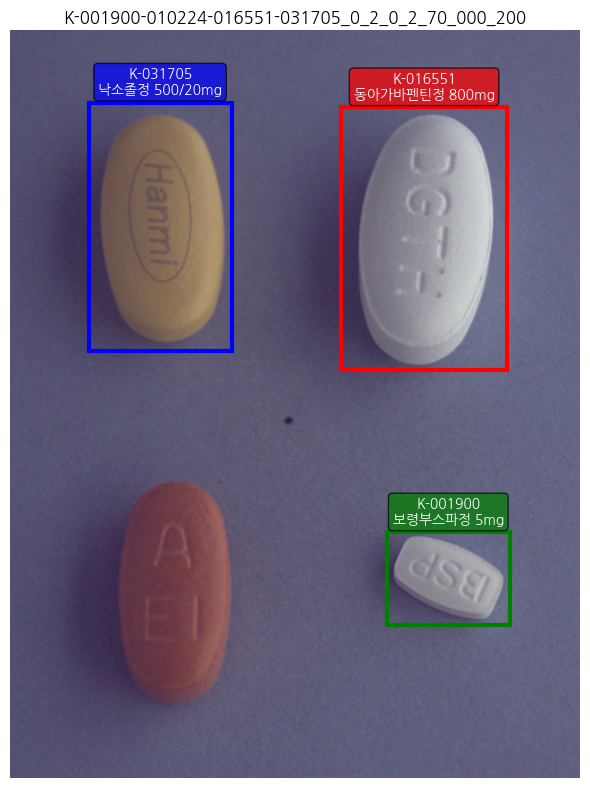

In [63]:
sample_filename = 'K-001900-010224-016551-031705_0_2_0_2_70_000_200'
visualize_drug_filenames_single_plot(df_train_test, df_drug, sample_filename, figsize=(6, 12))

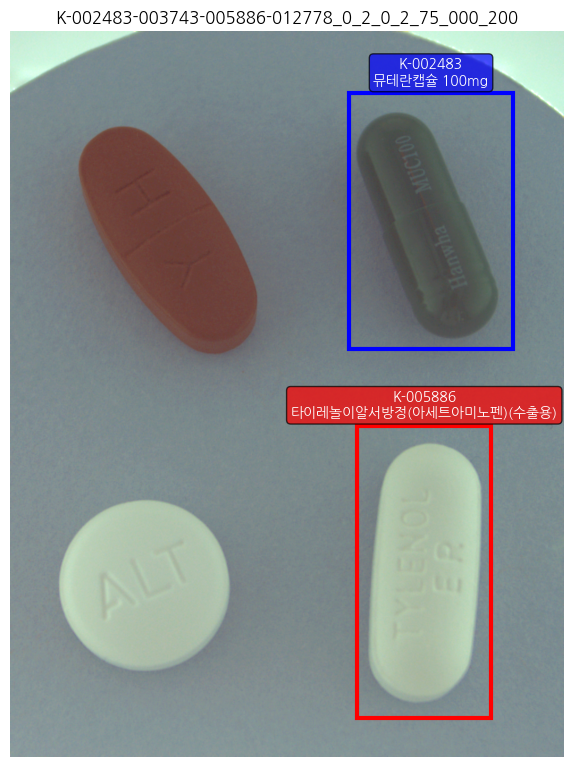

In [64]:
sample_filename = 'K-002483-003743-005886-012778_0_2_0_2_75_000_200'
visualize_drug_filenames_single_plot(df_train_test, df_drug, sample_filename, figsize=(6, 12))


=== 개선된 여러 label 시각화 (독립적인 plot들) ===
파일 개수: 6
파일명 예시: ['K-001900-016551-021026-044199_0_2_0_2_70_000_200', 'K-001900-016551-021026-044199_0_2_0_2_75_000_200', 'K-001900-016551-021026-044199_0_2_0_2_90_000_200']
총 6개 파일을 1개의 독립적인 plot으로 분할하여 표시합니다.


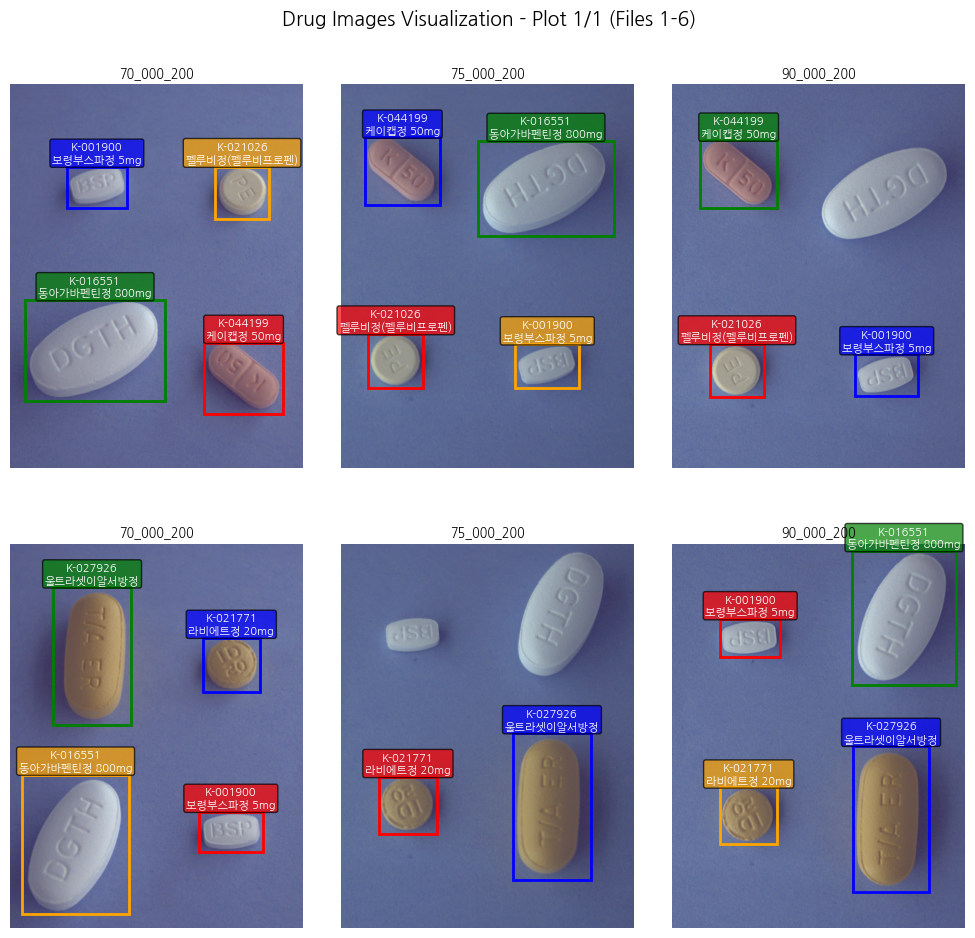

In [65]:
# 새로운 방식으로 여러 label 시각화 테스트
print("\n=== 개선된 여러 label 시각화 (독립적인 plot들) ===")
sample_filenames = df_train_test['filename'].dropna().unique()[1000:1006].tolist()
print(f"파일 개수: {len(sample_filenames)}")
print(f"파일명 예시: {sample_filenames[:3]}")

# 새로운 함수 사용 (최대 9개씩 나누어 표시)
visualize_drug_filenames(df_train_test, df_drug, sample_filenames,
                        figsize=(10, 15), max_files_per_plot=6)

In [66]:
# 필요한 경우 bbox의 좌표를 수정하기 위하여 함수 정의
def update_bbox_by_label_and_drug(df_train_test, label, drug_code, new_bbox_x, new_bbox_y, new_bbox_w, new_bbox_h, img_width=976, img_height=1280):
    """
    df_train_test의 특정 label과 약품코드에 해당하는 데이터의 bbox 및 yolo bbox를 수정

    Args:
        df_train_test: 훈련/테스트 데이터프레임
        label: 라벨 값 (예: 'K-001900-016548-018110-027926')
        drug_code: 약품코드 (예: 'K-001900')
        new_bbox_x: 새로운 bbox x 좌표
        new_bbox_y: 새로운 bbox y 좌표
        new_bbox_w: 새로운 bbox 너비
        new_bbox_h: 새로운 bbox 높이
        img_width: 이미지 너비 (YOLO 변환용)
        img_height: 이미지 높이 (YOLO 변환용)

    Returns:
        updated_count: 업데이트된 행의 수
        updated_indices: 업데이트된 행의 인덱스 리스트
    """
    # 조건에 맞는 데이터 찾기
    condition = (df_train_test['label'] == label) & (df_train_test['drug_N'] == drug_code)
    matching_indices = df_train_test[condition].index.tolist()

    if len(matching_indices) == 0:
        print(f"조건에 맞는 데이터가 없습니다: label='{label}', drug_code='{drug_code}'")
        return 0, []

    # YOLO 형식으로 변환
    x_center = (new_bbox_x + new_bbox_w / 2) / img_width
    y_center = (new_bbox_y + new_bbox_h / 2) / img_height
    w_norm = new_bbox_w / img_width
    h_norm = new_bbox_h / img_height

    # 기존 값 출력 (첫 번째 매칭 데이터)
    if len(matching_indices) > 0:
        first_idx = matching_indices[0]
        print(f"=== 수정 전 값 (인덱스 {first_idx}) ===")
        print(f"bbox: ({df_train_test.loc[first_idx, 'bbox_x']}, {df_train_test.loc[first_idx, 'bbox_y']}, "
              f"{df_train_test.loc[first_idx, 'bbox_w']}, {df_train_test.loc[first_idx, 'bbox_h']})")
        print(f"yolo: ({df_train_test.loc[first_idx, 'yolo_x']:.6f}, {df_train_test.loc[first_idx, 'yolo_y']:.6f}, "
              f"{df_train_test.loc[first_idx, 'yolo_w']:.6f}, {df_train_test.loc[first_idx, 'yolo_h']:.6f})")

    # 값 업데이트
    df_train_test.loc[condition, 'bbox_x'] = new_bbox_x
    df_train_test.loc[condition, 'bbox_y'] = new_bbox_y
    df_train_test.loc[condition, 'bbox_w'] = new_bbox_w
    df_train_test.loc[condition, 'bbox_h'] = new_bbox_h
    df_train_test.loc[condition, 'yolo_x'] = x_center
    df_train_test.loc[condition, 'yolo_y'] = y_center
    df_train_test.loc[condition, 'yolo_w'] = w_norm
    df_train_test.loc[condition, 'yolo_h'] = h_norm

    print(f"=== 수정 후 값 ===")
    print(f"bbox: ({new_bbox_x}, {new_bbox_y}, {new_bbox_w}, {new_bbox_h})")
    print(f"yolo: ({x_center:.6f}, {y_center:.6f}, {w_norm:.6f}, {h_norm:.6f})")
    print(f"업데이트된 행 수: {len(matching_indices)}")
    print(f"업데이트된 인덱스: {matching_indices}")

    return len(matching_indices), matching_indices

def update_bbox_interactive(df_train_test, df_drug):
    """
    대화형으로 bbox를 수정하는 함수

    Args:
        df_train_test: 훈련/테스트 데이터프레임
        df_drug: 약품 정보 데이터프레임
    """
    # 사용 가능한 label 목록 표시
    available_labels = df_train_test['label'].dropna().unique()
    print(f"사용 가능한 label 수: {len(available_labels)}")
    print("처음 10개 label:")
    for i, label in enumerate(available_labels[:10]):
        print(f"  {i+1}. {label}")

    # label 입력
    label = input("\n수정할 label을 입력하세요: ").strip()
    if label not in available_labels:
        print("존재하지 않는 label입니다.")
        return

    # 해당 label의 약품코드 목록 표시
    label_data = df_train_test[df_train_test['label'] == label]
    available_drugs = label_data['drug_N'].dropna().unique()
    print(f"\n'{label}'에서 사용 가능한 약품코드:")
    for i, drug in enumerate(available_drugs):
        drug_info = df_drug[df_drug['drug_N'] == drug]
        drug_name = drug_info['dl_name'].iloc[0] if not drug_info.empty else "이름 없음"
        print(f"  {i+1}. {drug} - {drug_name}")

    # 약품코드 입력
    drug_code = input("\n수정할 약품코드를 입력하세요: ").strip()
    if drug_code not in available_drugs:
        print("해당 label에 존재하지 않는 약품코드입니다.")
        return

    # 현재 bbox 값 표시
    current_data = df_train_test[(df_train_test['label'] == label) &
                                (df_train_test['drug_N'] == drug_code)].iloc[0]
    print(f"\n현재 bbox 값:")
    print(f"  x: {current_data['bbox_x']}")
    print(f"  y: {current_data['bbox_y']}")
    print(f"  w: {current_data['bbox_w']}")
    print(f"  h: {current_data['bbox_h']}")
    print(f"  이미지 크기: {current_data['width']} x {current_data['height']}")

    # 새로운 bbox 값 입력
    try:
        new_x = float(input(f"새로운 x 좌표 (현재: {current_data['bbox_x']}): ") or current_data['bbox_x'])
        new_y = float(input(f"새로운 y 좌표 (현재: {current_data['bbox_y']}): ") or current_data['bbox_y'])
        new_w = float(input(f"새로운 너비 (현재: {current_data['bbox_w']}): ") or current_data['bbox_w'])
        new_h = float(input(f"새로운 높이 (현재: {current_data['bbox_h']}): ") or current_data['bbox_h'])

        # 업데이트 실행
        updated_count, updated_indices = update_bbox_by_label_and_drug(
            df_train_test, label, drug_code, new_x, new_y, new_w, new_h,
            current_data['width'], current_data['height']
        )

        print(f"\n✅ 성공적으로 {updated_count}개 행이 업데이트되었습니다!")

    except ValueError as e:
        print(f"❌ 입력 오류: {e}")
    except Exception as e:
        print(f"❌ 업데이트 오류: {e}")

def visualize_bbox_update(df_train_test, df_drug, label, drug_code, before_after="both"):
    """
    bbox 수정 전후를 시각화하는 함수

    Args:
        df_train_test: 데이터프레임
        df_drug: 약품 정보 데이터프레임
        label: 라벨 값
        drug_code: 약품코드
        before_after: "before", "after", "both" 중 선택
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import cv2

    # 해당 데이터 찾기
    condition = (df_train_test['label'] == label) & (df_train_test['drug_N'] == drug_code)
    target_data = df_train_test[condition]

    if target_data.empty:
        print("조건에 맞는 데이터가 없습니다.")
        return

    sample_row = target_data.iloc[0]
    img_path = sample_row['imgfile']

    try:
        # 이미지 로드
        img = cv2.imread(img_path)
        if img is None:
            print("이미지 로드 실패")
            return

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 약품 정보
        drug_info = df_drug[df_drug['drug_N'] == drug_code]
        drug_name = drug_info['dl_name'].iloc[0] if not drug_info.empty else drug_code

        # 현재 bbox 표시
        fig, ax = plt.subplots(1, 1, figsize=(12, 8))
        ax.imshow(img_rgb)

        x, y, w, h = sample_row['bbox_x'], sample_row['bbox_y'], sample_row['bbox_w'], sample_row['bbox_h']

        # bbox 그리기
        rect = patches.Rectangle((x, y), w, h, linewidth=3,
                               edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # 텍스트 표시
        text = f'{drug_code}\n{drug_name}\nBBox: ({x:.0f}, {y:.0f}, {w:.0f}, {h:.0f})'
        bbox_props = dict(boxstyle="round,pad=0.3", facecolor='red', alpha=0.7)

        text_x = x + w/2
        text_y = max(0, y - 10)

        ax.text(text_x, text_y, text, fontsize=10, ha='center', va='bottom',
               color='white', weight='bold', bbox=bbox_props)

        ax.set_title(f'Label: {label}\n약품: {drug_code} - {drug_name}', fontsize=12)
        ax.axis('off')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"시각화 오류: {e}")

# # 사용 예시
# print("=== bbox 수정 함수 사용 예시 ===")
# print("1. 직접 수정:")
# print("   updated_count, indices = update_bbox_by_label_and_drug(")
# print("       df_train_test, 'K-001900-016548-018110-027926', 'K-001900',")
# print("       100, 200, 150, 100)")
# print()
# print("2. 대화형 수정:")
# print("   update_bbox_interactive(df_train_test, df_drug)")
# print()
# print("3. 시각화:")
# print("   visualize_bbox_update(df_train_test, df_drug, 'label', 'drug_code')")
# 실제 사용 예시 (주석 해제하여 사용)
# update_bbox_interactive(df_train_test, df_drug)

In [67]:
#visualize_bbox_update(df_train_test, df_drug, 'K-001900-016548-018110-027926', 'K-001900', before_after="both")

In [68]:
# updated_count, indices = update_bbox_by_label_and_drug(
#        df_train_test, 'K-001900-016548-018110-027926', 'K-001900',
#        100, 200, 150, 100)
# visualize_bbox_update(df_train_test, df_drug, 'K-001900-016548-018110-027926', 'K-001900', before_after="both")

In [69]:
# updated_count, indices = update_bbox_by_label_and_drug(
#     df_train_test, 'K-001900-016548-018110-027926', 'K-001900',
#     630, 894, 211, 133)
# visualize_bbox_update(df_train_test, df_drug, 'K-001900-016548-018110-027926', 'K-001900', before_after="both")

In [70]:
# df를 class_id의 개수 별로 정렬하고
# Train = False이고 Test = False 이면 Validation 로 하자
# Test = True 이면 Test 로 하자
# Validation을 Train에서 램덤하게 0.3 정도 Train=False 로 하자
df = df_train_test.copy()

# 1. class_id별로 정렬
df.sort_values('class_id', inplace=True)

# 2. Validation 셋 지정 (Train=True & Test=False 중에서 class별로 30% 랜덤 선택)
for class_id in df['class_id'].unique():
    idxs = df[(df['class_id'] == class_id) & (df['Train'] == True) & (df['Test'] == False)].index
    n_val = max(1, int(len(idxs) * 0.3)) if len(idxs) > 0 else 0
    if n_val > 0:
        val_idxs = np.random.choice(idxs, n_val, replace=False)
        df.loc[val_idxs, 'Train'] = False  # Validation으로 변경

# 3. set_type 컬럼 지정
df['set_type'] = np.where(df['Test'] == True, 'Test',
                  np.where(df['Train'] == True, 'Train', 'Validation'))

df_train_val_test = df.copy()


In [71]:
df_train_val_test.columns

Index(['filename', 'ext', 'file_name', 'path', 'label', 'drug0', 'drug1',
       'drug2', 'drug3', 'imgfile', 'Train', 'Test', 'drug_N', 'width',
       'height', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'yolo_x', 'yolo_y',
       'yolo_w', 'yolo_h', 'category_id', 'class_id', 'set_type'],
      dtype='object')

In [72]:
# 4. 결과 확인
df = df_train_val_test.copy()

print(df['set_type'].value_counts())
print(df.groupby('set_type')['drug_N'].nunique())

print('-' * 80)
print(df.shape, df_drug.shape)
print("filename 유니크 갯수:", df['filename'].nunique())
print("drug_N 유니크 갯수:", df['drug_N'].nunique())
print('-' * 80)
df.head_att(3)
print()
df.describe().head_att(10)
print('-' * 80)
print("df_drug 갯수:", len(df_drug))
print()
df_drug.head_att(3)
print()
df_drug.describe().head_att(10)

set_type
Train         3169
Validation    1312
Test           843
Name: count, dtype: int64
set_type
Test           0
Train         73
Validation    73
Name: drug_N, dtype: int64
--------------------------------------------------------------------------------
(5324, 26) (73, 20)
filename 유니크 갯수: 2317
drug_N 유니크 갯수: 73
--------------------------------------------------------------------------------
                                             filename  ext                                             file_name                                                                                                                                                                             path                         label    drug0    drug1    drug2    drug3                                                                                                                        imgfile Train  Test   drug_N width height bbox_x bbox_y bbox_w bbox_h yolo_x yolo_y yolo_w yolo_h category_id class_id   set

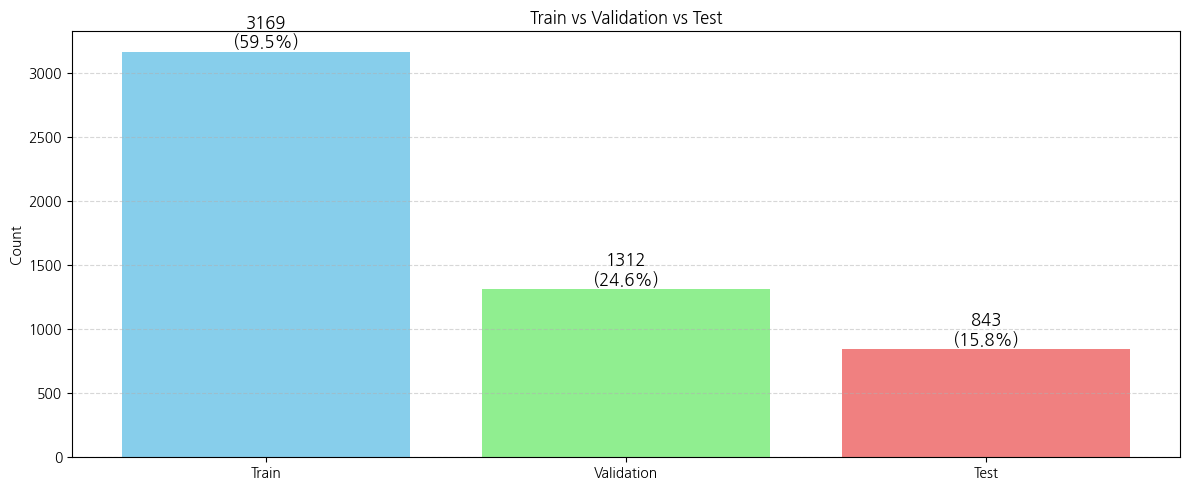

In [73]:
def plot_train_val_test(df):
    import matplotlib.pyplot as plt

    counts = {
        'Train': df['Train'].sum(),
        'Validation': (len(df) - df['Test'].sum()) - df['Train'].sum(),
        'Test': df['Test'].sum(),
    }

    total = counts['Train'] + counts['Validation'] + counts['Test']
    labels = ['Train', 'Validation', 'Test']
    values = [counts['Train'], counts['Validation'], counts['Test']]
    colors = ['skyblue', 'lightgreen', 'lightcoral']

    plt.figure(figsize=(12, 5))
    bars = plt.bar(labels, values, color=colors)

    # 막대 위에 개수 및 % 표시
    for bar, value in zip(bars, values):
        percent = value / total * 100 if total > 0 else 0
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{value}\n({percent:.1f}%)',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.title('Train vs Validation vs Test')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

df = df_train_val_test.copy()
plot_train_val_test(df)

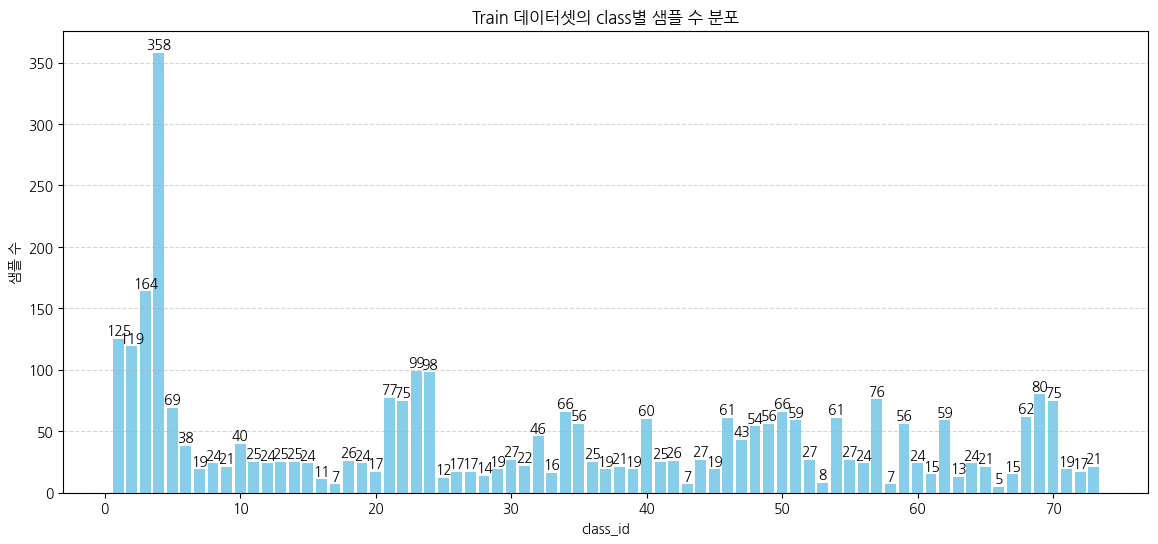

In [74]:
def plot_train_class_distribution(df):
    import matplotlib.pyplot as plt

    # Train만 필터링
    df_train = df[df['set_type'] == 'Train']
    class_counts = df_train['class_id'].value_counts().sort_index()

    plt.figure(figsize=(14, 6))
    bars = plt.bar(class_counts.index, class_counts.values, color='skyblue')

    # 각 막대 위에 개수 표시
    for bar, value in zip(bars, class_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{value}', ha='center', va='bottom', fontsize=10)

    plt.title('Train 데이터셋의 class별 샘플 수 분포')
    plt.xlabel('class_id')
    plt.ylabel('샘플 수')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
plot_train_class_distribution(df)

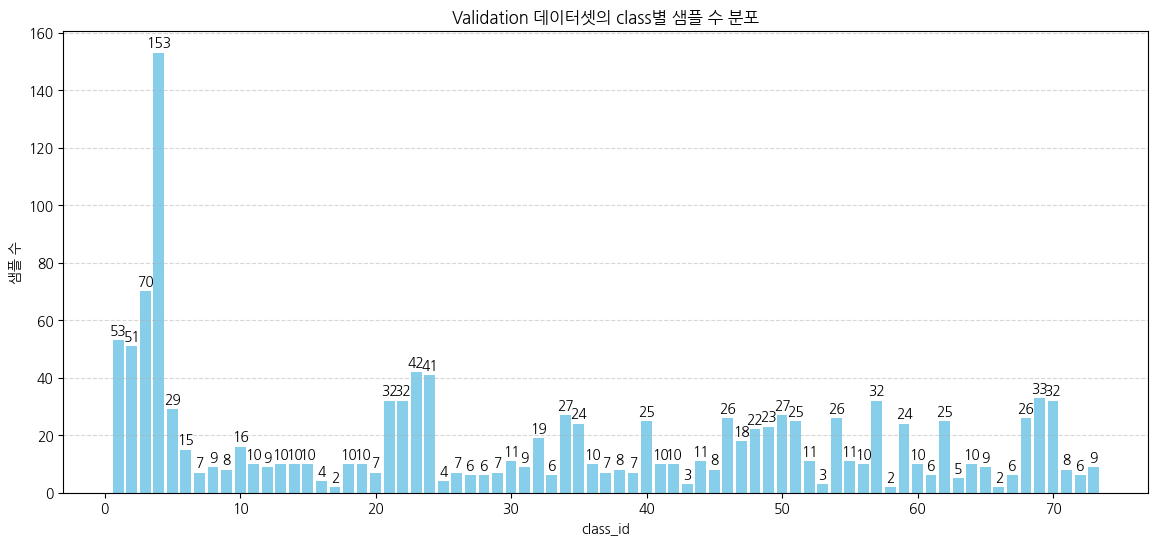

In [75]:
def plot_validation_class_distribution(df):
    import matplotlib.pyplot as plt

    # Validation만 필터링
    df_val = df[df['set_type'] == 'Validation']
    class_counts = df_val['class_id'].value_counts().sort_index()

    plt.figure(figsize=(14, 6))
    bars = plt.bar(class_counts.index, class_counts.values, color='skyblue')

    # 각 막대 위에 개수 표시
    for bar, value in zip(bars, class_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{value}', ha='center', va='bottom', fontsize=10)

    plt.title('Validation 데이터셋의 class별 샘플 수 분포')
    plt.xlabel('class_id')
    plt.ylabel('샘플 수')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plot_validation_class_distribution(df)

In [76]:
drug_counts = df['drug_N'].value_counts().sort_values(ascending=False)
drug_counts.head_att(100)

인덱스    count  
index     count  
K-003483  511    
K-003351  234    
K-001900  178    
K-002483  170    
K-016548  141    
K-016551  139    
K-035206  113    
K-016232  109    
K-029667  108    
K-016262  107    
K-036637  107    
K-003544  98     
K-020238  93     
K-027733  93     
K-034597  88     
K-025367  87     
K-028763  87     
K-022347  85     
K-027777  84     
K-031885  84     
K-020877  80     
K-030308  80     
K-027653  79     
K-025469  76     
K-019861  65     
K-025438  61     
K-005094  56     
K-003743  53     
K-029345  38     
K-027926  38     
K-019552  38     
K-023223  38     
K-012778  36     
K-022627  36     
K-005886  35     
K-006563  35     
K-022362  35     
K-010221  35     
K-021026  35     
K-031705  34     
K-033009  34     
K-012081  34     
K-013395  34     
K-029451  34     
K-004378  33     
K-006192  33     
K-019607  31     
K-044199  30     
K-033208  30     
K-021771  29     
K-004543  29     
K-038162  27     
K-024850  27     
K-003832  26 

drug_N별 샘플 갯수 상위 10개:
인덱스    count  
index     count  
K-003483  511    
K-003351  234    
K-001900  178    
K-002483  170    
K-016548  141    
drug_N
K-027993    11
K-023203    10
K-012420     9
K-029871     9
K-033878     7
Name: count, dtype: int64


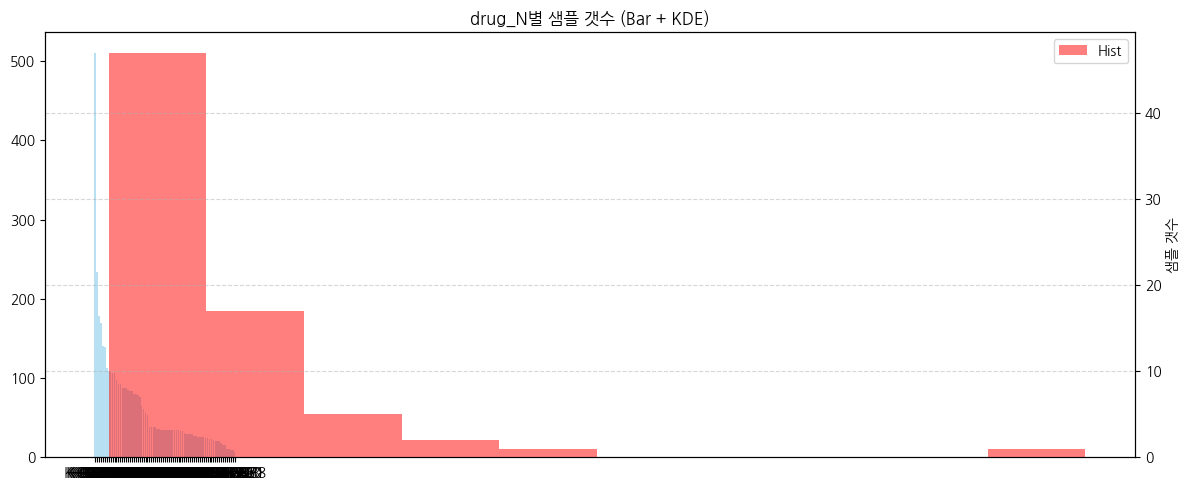

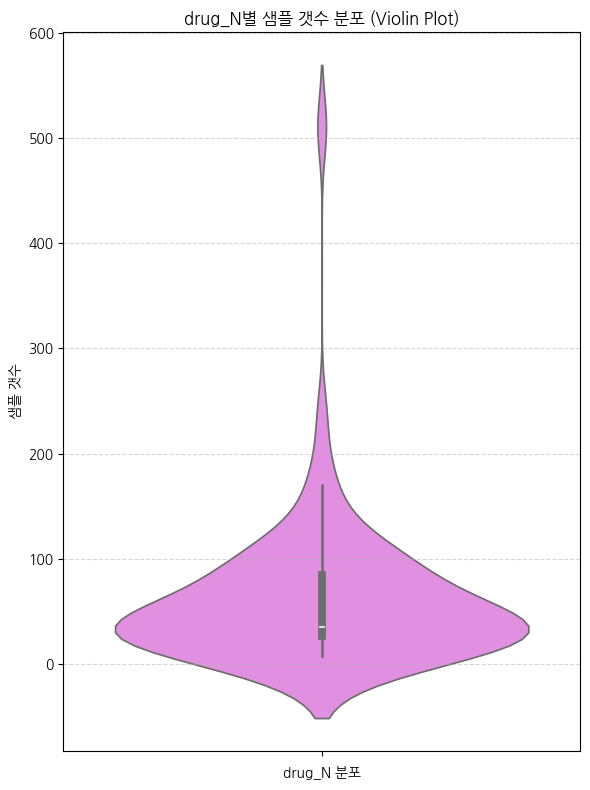

In [77]:
# drug_N별 데이터 분포도(샘플 갯수) 살펴보기
def plot_dfrug_distribution(df):
    # drug_N별 샘플 갯수 집계
    drug_counts = df['drug_N'].value_counts().sort_values(ascending=False)

    print("drug_N별 샘플 갯수 상위 10개:")
    drug_counts.head_att(5)
    print(drug_counts.tail(5))

    plt.figure(figsize=(12,5))
    # 막대그래프
    plt.bar(drug_counts.index, drug_counts.values, width=0.8, color='skyblue', alpha=0.6, label='Bar')
    # KDE 곡선 (x축은 drug_N별 샘플 갯수)
    ax2 = plt.gca().twinx()
    # sns.kdeplot(drug_counts.values, color='red', linewidth=2, ax=ax2, label='KDE')
    # sns.histplot(drug_counts.values, kde=True, color='red', linewidth=2, ax=ax2, label='KDE')
    ax2.hist(drug_counts.values, color='red', alpha=0.5, label='Hist')
    ax2.set_ylabel('밀도')
    ax2.grid(axis='y', linestyle='--', alpha=0.5)  # 가로 그리드 라인 추가
    plt.title('drug_N별 샘플 갯수 (Bar + KDE)')
    plt.xlabel('drug_N')
    plt.ylabel('샘플 갯수')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

plot_dfrug_distribution(df)

def plot_dfrug_distribution_violin(df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # drug_N별 샘플 갯수 집계
    drug_counts = df['drug_N'].value_counts()

    fig, ax = plt.subplots(figsize=(6,8))
    sns.violinplot(y=drug_counts.values, color='violet', ax=ax)
    ax.set_title('drug_N별 샘플 갯수 분포 (Violin Plot)')
    ax.set_ylabel('샘플 갯수')
    ax.set_xlabel('drug_N 분포')
    ax.grid(axis='y', linestyle='--', alpha=0.5)  # 가로 그리드 라인 추가
    plt.tight_layout()
    plt.show()

plot_dfrug_distribution_violin(df)


In [78]:
"""
                                              filename  ext                                             file_name                                                                                                                                                                             path                         label    drug0    drug1    drug2    drug3 Train  Test   drug_N width height bbox_x bbox_y bbox_w bbox_h yolo_x yolo_y yolo_w yolo_h class_id   set_type
  872 K-001900-016548-018110-027926_0_2_0_2_75_000_200 json K-001900-016548-018110-027926_0_2_0_2_75_000_200.json d:\dataset\local_kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016548-018110-027926_json\K-001900\K-001900-016548-018110-027926_0_2_0_2_75_000_200.json K-001900-016548-018110-027926 K-001900 K-016548 K-018110 K-027926 False False K-001900   976   1280    142    241    200    127  0.248 0.2379 0.2049 0.0992        1 Validation
  870 K-001900-016548-018110-027926_0_2_0_2_70_000_200 json K-001900-016548-018110-027926_0_2_0_2_70_000_200.json d:\dataset\local_kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016548-018110-027926_json\K-001900\K-001900-016548-018110-027926_0_2_0_2_70_000_200.json K-001900-016548-018110-027926 K-001900 K-016548 K-018110 K-027926 False False K-001900   976   1280    630    894    211    133 0.7536 0.7504 0.2162 0.1039        1 Validation
  867 K-001900-016548-018110-021026_0_2_0_2_90_000_200 json K-001900-016548-018110-021026_0_2_0_2_90_000_200.json d:\dataset\local_kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016548-018110-021026_json\K-001900\K-001900-016548-018110-021026_0_2_0_2_90_000_200.json K-001900-016548-018110-021026 K-001900 K-016548 K-018110 K-021026  True False K-001900   976   1280    621    887    208    143 0.7428 0.7488 0.2131 0.1117        1      Train
  862 K-001900-016548-018110-021026_0_2_0_2_75_000_200 json K-001900-016548-018110-021026_0_2_0_2_75_000_200.json d:\dataset\local_kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016548-018110-021026_json\K-001900\K-001900-016548-018110-021026_0_2_0_2_75_000_200.json K-001900-016548-018110-021026 K-001900 K-016548 K-018110 K-021026  True False K-001900   976   1280    596    854    212    148 0.7193  0.725 0.2172 0.1156        1      Train
  859 K-001900-016548-018110-021026_0_2_0_2_70_000_200 json K-001900-016548-018110-021026_0_2_0_2_70_000_200.json d:\dataset\local_kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016548-018110-021026_json\K-001900\K-001900-016548-018110-021026_0_2_0_2_70_000_200.json K-001900-016548-018110-021026 K-001900 K-016548 K-018110 K-021026 False False K-001900   976   1280    173    279    201    141 0.2802  0.273 0.2059 0.1102        1 Validation
 1473 K-001900-016551-029345-033208_0_2_0_2_70_000_200 json K-001900-016551-029345-033208_0_2_0_2_70_000_200.json d:\dataset\local_kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016551-029345-033208_json\K-001900\K-001900-016551-029345-033208_0_2_0_2_70_000_200.json K-001900-016551-029345-033208 K-001900 K-016551 K-029345 K-033208  True False K-001900   976   1280    687    807    132    207 0.7715 0.7113 0.1352 0.1617        1      Train
 1468 K-001900-016551-027926-044199_0_2_0_2_90_000_200 json K-001900-016551-027926-044199_0_2_0_2_90_000_200.json d:\dataset\local_kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016551-027926-044199_json\K-001900\K-001900-016551-027926-044199_0_2_0_2_90_000_200.json K-001900-016551-027926-044199 K-001900 K-016551 K-027926 K-044199  True False K-001900   976   1280    156    248    202    128 0.2633 0.2437  0.207    0.1        1      Train
 1493 K-001900-016551-029451-033208_0_2_0_2_70_000_200 json K-001900-016551-029451-033208_0_2_0_2_70_000_200.json d:\dataset\local_kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016551-029451-033208_json\K-001900\K-001900-016551-029451-033208_0_2_0_2_70_000_200.json K-001900-016551-029451-033208 K-001900 K-016551 K-029451 K-033208  True False K-001900   976   1280    643    845    189    190 0.7556 0.7344 0.1936 0.1484        1      Train
 1492 K-001900-016551-029345-044199_0_2_0_2_90_000_200 json K-001900-016551-029345-044199_0_2_0_2_90_000_200.json d:\dataset\local_kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016551-029345-044199_json\K-001900\K-001900-016551-029345-044199_0_2_0_2_90_000_200.json K-001900-016551-029345-044199 K-001900 K-016551 K-029345 K-044199  True False K-001900   976   1280    179    268    131    201 0.2505 0.2879 0.1342  0.157        1      Train
 1485 K-001900-016551-029345-044199_0_2_0_2_70_000_200 json K-001900-016551-029345-044199_0_2_0_2_70_000_200.json d:\dataset\local_kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016551-029345-044199_json\K-001900\K-001900-016551-029345-044199_0_2_0_2_70_000_200.json K-001900-016551-029345-044199 K-001900 K-016551 K-029345 K-044199 False False K-001900   976   1280    688    806    129    208  0.771 0.7109 0.1322 0.1625        1 Validation
"""

'\n                                              filename  ext                                             file_name                                                                                                                                                                             path                         label    drug0    drug1    drug2    drug3 Train  Test   drug_N width height bbox_x bbox_y bbox_w bbox_h yolo_x yolo_y yolo_w yolo_h class_id   set_type\n  872 K-001900-016548-018110-027926_0_2_0_2_75_000_200 json K-001900-016548-018110-027926_0_2_0_2_75_000_200.json d:\\dataset\\local_kaggle_code_it_data\x07i04-level1-project.zip.unzip\train_annotations\\K-001900-016548-018110-027926_json\\K-001900\\K-001900-016548-018110-027926_0_2_0_2_75_000_200.json K-001900-016548-018110-027926 K-001900 K-016548 K-018110 K-027926 False False K-001900   976   1280    142    241    200    127  0.248 0.2379 0.2049 0.0992        1 Validation\n  870 K-001900-016548-018110-027926_0_2_0_2_70_0

In [79]:
def create_yolo_dataset(df, yolo_dataset_path, use_jpg=True):
    """
                                              filename  ext                                             file_name                                                                                                                                                                             path                         label    drug0    drug1    drug2    drug3 Train  Test   drug_N width height bbox_x bbox_y bbox_w bbox_h yolo_x yolo_y yolo_w yolo_h class_id   set_type
  872 K-001900-016548-018110-027926_0_2_0_2_75_000_200 json K-001900-016548-018110-027926_0_2_0_2_75_000_200.json d:\dataset\local_kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016548-018110-027926_json\K-001900\K-001900-016548-018110-027926_0_2_0_2_75_000_200.json K-001900-016548-018110-027926 K-001900 K-016548 K-018110 K-027926 False False K-001900   976   1280    142    241    200    127  0.248 0.2379 0.2049 0.0992        1 Validation
  870 K-001900-016548-018110-027926_0_2_0_2_70_000_200 json K-001900-016548-018110-027926_0_2_0_2_70_000_200.json d:\dataset\local_kaggle_code_it_data\ai04-level1-project.zip.unzip\train_annotations\K-001900-016548-018110-027926_json\K-001900\K-001900-016548-018110-027926_0_2_0_2_70_000_200.json K-001900-016548-018110-027926 K-001900 K-016548 K-018110 K-027926 False False K-001900   976   1280    630    894    211    133 0.7536 0.7504 0.2162 0.1039        1 Validation

dataset/
├── images/
│   ├── train/
│   │   ├── image1.jpg
│   │   ├── image2.jpg
│   │   └── ...
│   ├── val/
│   │   ├── val_image1.jpg
│   │   └── ...
│   └── test/ (선택적)
└── labels/
    ├── train/
    │   ├── image1.txt
    │   ├── image2.txt
    │   └── ...
    ├── val/
    │   ├── val_image1.txt
    │   └── ...
    └── test/ (선택적)

    DataFrame df_convert_yolo를 만들고 df를 복사하고 to yolo_image_train, yolo_image_val, yolo_label_train, yolo_label_val를 만든다.
    df의 Train 컬럼을 참고 하면 된다.
    df_convert_yolo를 yolo_dataset_path에 저장한다. (원복등에 참고 할 수 있을 것이다.)

    만들어진 df_convert_yolo 를 이용하여 images를 yolo_image_train, yolo_image_val에 이동시킨다.
    전체적인 데이타 용량이 큼으로 파일을 이동시키는 방식으로 한다.

    """

    images_train_dir = os.path.join(yolo_dataset_path, 'images', 'train')
    images_val_dir = os.path.join(yolo_dataset_path, 'images', 'val')
    images_test_dir = os.path.join(yolo_dataset_path, 'images', 'test')
    labels_train_dir = os.path.join(yolo_dataset_path, 'labels', 'train')
    labels_val_dir = os.path.join(yolo_dataset_path, 'labels', 'val')
    labels_test_dir = os.path.join(yolo_dataset_path, 'labels', 'test')

    df.sort_values('filename', inplace=True)
    df = df.reset_index(drop=True)

    pbar = tqdm(df.iterrows(), total=len(df), mininterval=3, desc="Creating YOLO dataset")
    for idx, row in pbar:
        set_type = row.get('set_type', 'Unknown')
        img_dst, label_dst = None, None

        filename = row['filename']
        label_name = row['label']
        # 파일명에 _순서 붙이기
        if use_jpg:
            base_img_name = f"{filename}.jpg"
        else:
            base_img_name = f"{filename}.png"
        base_label_name = f"{filename}.txt"

        if set_type == 'Train':
            img_dst = os.path.join(images_train_dir, base_img_name)
            label_dst = os.path.join(labels_train_dir, base_label_name)
        elif set_type == 'Validation':
            img_dst = os.path.join(images_val_dir, base_img_name)
            label_dst = os.path.join(labels_val_dir, base_label_name)
        elif set_type == 'Test':
            img_dst = os.path.join(images_test_dir, base_img_name)
            label_dst = os.path.join(labels_test_dir, base_label_name)
        else:
            continue

        df.loc[idx, 'yolo_image'] = img_dst
        df.loc[idx, 'yolo_label'] = label_dst

        if idx % 100 == 0:
            pbar.set_postfix_str(base_img_name)

    return df

def create_yolo_df(yolo_path, ignore=True):
    df = df_train_val_test.copy()
    df_yolo = helper.pd_checkout("df_codeit04_yolo", commit_dir=drive_root())
    if df_yolo.empty | ignore:
        df_yolo = create_yolo_dataset(df, yolo_path)
        helper.pd_commit(df_yolo, "df_codeit04_yolo", commit_dir=drive_root())
    else:
        print("df_yolo 로드됨")
    return df_yolo, yolo_path

yolo_path  = os.path.join(root_dir, "yolo")
df_yolo, yolo_path = create_yolo_df(yolo_path, ignore=True)

Creating YOLO dataset: 100%|██████████| 5324/5324 [00:01<00:00, 3733.87it/s, K-003544-010221-016551-033009_0_2_0_2_90_000_200.jpg]

✅ 커밋 완료: 7186a0384681 | 2025-09-19 19:54:33 | df_codeit04_yolo


In [80]:
print(df_yolo.shape)


print(df_yolo['set_type'].value_counts())
print(df_yolo.groupby('set_type')['drug_N'].nunique())

print('-' * 80)
print(df_yolo.shape)
print("filename 유니크 갯수:", df_yolo['filename'].nunique())
print("drug_N 유니크 갯수:", df_yolo['drug_N'].nunique())
print('-' * 80)

df_yolo.describe().head_att(10)
df_yolo.iloc[2000:2002].head_att(2)


(5324, 28)
set_type
Train         3169
Validation    1312
Test           843
Name: count, dtype: int64
set_type
Test           0
Train         73
Validation    73
Name: drug_N, dtype: int64
--------------------------------------------------------------------------------
(5324, 28)
filename 유니크 갯수: 2317
drug_N 유니크 갯수: 73
--------------------------------------------------------------------------------
          width    height   bbox_x  bbox_y   bbox_w   bbox_h yolo_x yolo_y yolo_w yolo_h category_id class_id
 count     5324      5324     5324    5324     5324     5324   5324   5324   5324   5324        4481     4481
  mean 821.4606 1077.3253 299.4138 406.117 218.3535 243.1527 0.4186 0.4123 0.2237   0.19  17637.1687  30.6755
   std 356.3312  467.3196 255.2435 330.202 114.4975 150.4758 0.2856  0.278 0.1173 0.1176  11691.2714  23.2197
   min        0         0        0       0        0        0      0      0      0      0        1899        1
   25%      976      1280       84     122     

## 3. Image to Yolo File
- resize Iamge 640 x 480

In [81]:
import cv2
import numpy as np
from sklearn.cluster import KMeans

def create_rounded_mask(width, height, radius):
    """OpenCV를 사용한 둥근 네모 마스크 생성"""
    mask = np.zeros((height, width), dtype=np.uint8)

    if radius <= 0:
        mask[:, :] = 255
        return mask

    # 반지름이 너무 크면 조정
    radius = min(radius, min(width, height) // 2)

    # 둥근 사각형 그리기
    # 중앙 사각형들
    cv2.rectangle(mask, (radius, 0), (width - radius, height), 255, -1)
    cv2.rectangle(mask, (0, radius), (width, height - radius), 255, -1)

    # 네 모서리에 원 그리기
    cv2.circle(mask, (radius, radius), radius, 255, -1)  # 좌상단
    cv2.circle(mask, (width - radius, radius), radius, 255, -1)  # 우상단
    cv2.circle(mask, (radius, height - radius), radius, 255, -1)  # 좌하단
    cv2.circle(mask, (width - radius, height - radius), radius, 255, -1)  # 우하단

    return mask

def get_combined_rect_with_margin(bboxes, img_shape, margin=20):
    """
    여러 객체의 bbox를 합친 전체 rect를 계산하고 마진을 추가

    Args:
        bboxes: 객체들의 bbox 리스트 [(x, y, w, h), ...]
        img_shape: 이미지 크기 (height, width)
        margin: 추가할 마진 크기

    Returns:
        combined_rect: (x, y, w, h) 형태의 합쳐진 rect
    """
    if not bboxes:
        return None

    h, w = img_shape[:2]

    # 모든 bbox의 최소/최대 좌표 계산
    min_x = min(bbox[0] for bbox in bboxes)
    min_y = min(bbox[1] for bbox in bboxes)
    max_x = max(bbox[0] + bbox[2] for bbox in bboxes)
    max_y = max(bbox[1] + bbox[3] for bbox in bboxes)

    # 마진 추가
    min_x = max(0, min_x - margin)
    min_y = max(0, min_y - margin)
    max_x = min(w, max_x + margin)
    max_y = min(h, max_y + margin)

    return (min_x, min_y, max_x - min_x, max_y - min_y)

def extract_background_color_advanced(img, combined_rect, corner_radius=20, sample_size=1000):
    """
    둥근 모서리로 잘라낸 객체 영역을 제외한 배경에서 평균 색상 추출

    Args:
        img: 원본 이미지
        combined_rect: 객체들의 합쳐진 rect (x, y, w, h)
        corner_radius: 둥근 모서리 반지름
        sample_size: 배경색 추출을 위한 샘플 픽셀 수

    Returns:
        bg_color: 배경색 (B, G, R)
    """
    h, w = img.shape[:2]

    # 전체 마스크 (배경 = 255, 객체 = 0)
    mask = np.ones((h, w), dtype=np.uint8) * 255

    if combined_rect is not None:
        x, y, rect_w, rect_h = map(int, combined_rect)

        # 둥근 모서리 마스크 생성
        rounded_mask = create_rounded_mask(rect_w, rect_h, corner_radius)

        # 객체 영역에 둥근 마스크 적용 (해당 영역을 0으로 설정)
        if (x + rect_w <= w and y + rect_h <= h and
            x >= 0 and y >= 0 and rect_w > 0 and rect_h > 0):
            # 둥근 마스크를 이용해 객체 영역 제거
            mask[y:y+rect_h, x:x+rect_w] = rounded_mask

    # 배경 영역 픽셀 추출
    background_pixels = img[mask == 255]

    if len(background_pixels) == 0:
        # 배경이 없으면 ImageNet 평균값 사용
        return np.array([123, 117, 104], dtype=np.uint8)

    # 너무 많은 픽셀이 있으면 랜덤 샘플링
    if len(background_pixels) > sample_size:
        indices = np.random.choice(len(background_pixels), sample_size, replace=False)
        background_pixels = background_pixels[indices]

    # K-means를 사용해 주요 색상 추출
    try:
        kmeans = KMeans(n_clusters=min(3, len(background_pixels)), random_state=42, n_init=10)
        kmeans.fit(background_pixels)

        # 가장 많은 픽셀을 가진 클러스터의 중심색을 배경색으로 선택
        labels = kmeans.labels_
        cluster_counts = np.bincount(labels)
        dominant_cluster = np.argmax(cluster_counts)
        bg_color = kmeans.cluster_centers_[dominant_cluster].astype(np.uint8)

    except:
        # K-means 실패시 평균값 사용
        bg_color = np.mean(background_pixels, axis=0).astype(np.uint8)

    return bg_color

def create_cleaned_image_with_rounded_crop(img, combined_rect, bg_color, corner_radius=20):
    """
    둥근 모서리로 잘라낸 객체 영역을 제외하고 배경색으로 채운 이미지 생성

    Args:
        img: 원본 이미지
        combined_rect: 객체들의 합쳐진 rect (x, y, w, h)
        bg_color: 배경색
        corner_radius: 둥근 모서리 반지름

    Returns:
        cleaned_img: 정리된 이미지
    """
    h, w = img.shape[:2]
    cleaned_img = np.full_like(img, bg_color)

    if combined_rect is not None:
        x, y, rect_w, rect_h = map(int, combined_rect)

        # 안전 체크
        if (x + rect_w <= w and y + rect_h <= h and
            x >= 0 and y >= 0 and rect_w > 0 and rect_h > 0):

            # 둥근 모서리 마스크 생성
            rounded_mask = create_rounded_mask(rect_w, rect_h, corner_radius)

            # 객체 영역만 복사 (둥근 모서리 적용)
            roi = img[y:y+rect_h, x:x+rect_w]

            # 마스크가 255인 부분만 복사
            mask_3ch = cv2.cvtColor(rounded_mask, cv2.COLOR_GRAY2BGR) / 255.0

            cleaned_roi = (roi * mask_3ch +
                          bg_color.reshape(1, 1, 3) * (1 - mask_3ch)).astype(np.uint8)

            cleaned_img[y:y+rect_h, x:x+rect_w] = cleaned_roi

    return cleaned_img

def resize_with_aspect_ratio_and_bg_advanced(img, target_size=(640, 480), bg_color=None):
    """
    비율을 유지하며 리사이즈하고, 배경색으로 패딩 추가
    """
    if bg_color is None:
        bg_color = [0, 0, 0]

    h, w = img.shape[:2]
    target_w, target_h = target_size

    # 스케일 계산 (비율 유지)
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)

    # 리사이즈
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # 배경색으로 패딩된 캔버스 생성
    result = np.full((target_h, target_w, 3), bg_color, dtype=np.uint8)

    # 중앙에 배치
    x_offset = (target_w - new_w) // 2
    y_offset = (target_h - new_h) // 2
    result[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    return result


In [82]:
def create_individual_object_masks(img, bboxes, corner_radius=20):
    """
    각 객체별로 개별 마스크를 생성

    Args:
        img: 원본 이미지
        bboxes: 객체들의 bbox 리스트 [(x, y, w, h), ...]
        corner_radius: 둥근 모서리 반지름

    Returns:
        object_masks: 각 객체의 마스크 리스트
        combined_mask: 모든 객체를 합친 마스크
    """
    h, w = img.shape[:2]
    object_masks = []
    combined_mask = np.zeros((h, w), dtype=np.uint8)

    for bbox in bboxes:
        x, y, bbox_w, bbox_h = map(int, bbox)

        # 안전 체크
        if (x + bbox_w <= w and y + bbox_h <= h and
            x >= 0 and y >= 0 and bbox_w > 0 and bbox_h > 0):

            # 개별 객체 마스크 생성
            object_mask = np.zeros((h, w), dtype=np.uint8)

            # 둥근 모서리 마스크 생성
            rounded_mask = create_rounded_mask(bbox_w, bbox_h, corner_radius)

            # 해당 위치에 마스크 적용
            object_mask[y:y+bbox_h, x:x+bbox_w] = rounded_mask

            object_masks.append(object_mask)

            # 전체 마스크에 추가 (OR 연산)
            combined_mask = cv2.bitwise_or(combined_mask, object_mask)

    return object_masks, combined_mask

In [83]:

def create_cleaned_image_with_individual_objects(img, bboxes, bg_color, corner_radius=20):
    """
    개별 객체들만 유지하고 나머지는 배경색으로 채운 이미지 생성

    Args:
        img: 원본 이미지
        bboxes: 라벨링된 객체들의 bbox 리스트 [(x, y, w, h), ...]
        bg_color: 배경색
        corner_radius: 둥근 모서리 반지름

    Returns:
        cleaned_img: 정리된 이미지 (라벨링된 객체만 유지)
    """
    h, w = img.shape[:2]

    # 배경색으로 채운 캔버스 생성
    cleaned_img = np.full_like(img, bg_color)

    if not bboxes:
        return cleaned_img

    # 각 객체별 마스크 생성
    object_masks, combined_mask = create_individual_object_masks(img, bboxes, corner_radius)

    # 각 객체를 개별적으로 복사
    for bbox, object_mask in zip(bboxes, object_masks):
        x, y, bbox_w, bbox_h = map(int, bbox)

        # 안전 체크
        if (x + bbox_w <= w and y + bbox_h <= h and
            x >= 0 and y >= 0 and bbox_w > 0 and bbox_h > 0):

            # 해당 영역의 마스크와 원본 이미지를 이용해 객체만 추출
            roi_mask = object_mask[y:y+bbox_h, x:x+bbox_w]
            roi_img = img[y:y+bbox_h, x:x+bbox_w]
            roi_bg = np.full_like(roi_img, bg_color)

            # 마스크 적용 (객체 부분만 원본, 나머지는 배경색)
            mask_3ch = cv2.cvtColor(roi_mask, cv2.COLOR_GRAY2BGR) / 255.0
            blended_roi = (roi_img * mask_3ch + roi_bg * (1 - mask_3ch)).astype(np.uint8)

            # 정리된 이미지에 복사
            cleaned_img[y:y+bbox_h, x:x+bbox_w] = blended_roi

    return cleaned_img


In [84]:
def extract_individual_objects_with_background(img, bboxes, bg_color, corner_radius=20):
    """
    각 객체를 개별적으로 추출하여 배경 위에 올리는 함수

    Args:
        img: 원본 이미지
        bboxes: 객체들의 bbox 리스트 [(x, y, w, h), ...]
        bg_color: 배경색
        corner_radius: 둥근 모서리 반지름

    Returns:
        result_img: 각 객체가 배경 위에 합성된 최종 이미지
        individual_objects: 각 객체별로 추출된 이미지 리스트
    """
    h, w = img.shape[:2]

    # 1. 기본 배경색으로 결과 이미지 초기화
    result_img = np.full_like(img, bg_color)

    # 2. bg.png가 있으면 배경으로 사용
    bg_img_path = "bg.png"
    if os.path.exists(bg_img_path):
        try:
            bg_img = cv2.imread(bg_img_path)
            if bg_img is not None:
                # 원본 이미지와 크기가 다르면 리사이즈
                if bg_img.shape != img.shape:
                    bg_img = cv2.resize(bg_img, (w, h), interpolation=cv2.INTER_AREA)
                result_img = bg_img.copy()
            else:
                print(f"Warning: bg.png 파일을 읽을 수 없습니다. 배경색을 사용합니다.")
        except Exception as e:
            print(f"Warning: bg.png 로드 중 오류 발생: {e}. 배경색을 사용합니다.")

    # 3. 각 객체별 마스크 생성
    object_masks, combined_mask = create_individual_object_masks(img, bboxes, corner_radius)

    # 4. 개별 객체 추출 및 배경에 합성
    individual_objects = []

    for i, (bbox, object_mask) in enumerate(zip(bboxes, object_masks)):
        x, y, bbox_w, bbox_h = map(int, bbox)

        # 안전성 검사
        if (x + bbox_w <= w and y + bbox_h <= h and
            x >= 0 and y >= 0 and bbox_w > 0 and bbox_h > 0):

            # 개별 객체용 배경 생성 (배경색 또는 bg.png)
            if os.path.exists(bg_img_path):
                try:
                    bg_img = cv2.imread(bg_img_path)
                    if bg_img is not None and bg_img.shape == img.shape:
                        object_on_bg = bg_img.copy()
                    else:
                        object_on_bg = np.full_like(img, bg_color)
                except:
                    object_on_bg = np.full_like(img, bg_color)
            else:
                object_on_bg = np.full_like(img, bg_color)

            # 객체 영역 추출
            roi_mask = object_mask[y:y+bbox_h, x:x+bbox_w]
            roi_img = img[y:y+bbox_h, x:x+bbox_w]
            roi_bg = object_on_bg[y:y+bbox_h, x:x+bbox_w]

            # 마스크 적용하여 객체만 추출하고 배경과 합성
            mask_3ch = cv2.cvtColor(roi_mask, cv2.COLOR_GRAY2BGR) / 255.0
            blended_roi = (roi_img * mask_3ch + roi_bg * (1 - mask_3ch)).astype(np.uint8)

            # 개별 객체를 배경에 배치
            object_on_bg[y:y+bbox_h, x:x+bbox_w] = blended_roi
            individual_objects.append(object_on_bg)

            # 결과 이미지에도 현재 객체 합성
            result_roi = result_img[y:y+bbox_h, x:x+bbox_w]
            final_roi = (roi_img * mask_3ch + result_roi * (1 - mask_3ch)).astype(np.uint8)
            result_img[y:y+bbox_h, x:x+bbox_w] = final_roi

    return result_img, individual_objects

In [85]:

def extract_background_color_from_unlabeled_areas(img, bboxes, corner_radius=20, sample_size=1000):
    """
    라벨링된 객체들을 제외한 영역에서 배경색 추출

    Args:
        img: 원본 이미지
        bboxes: 라벨링된 객체들의 bbox 리스트
        corner_radius: 둥근 모서리 반지름
        sample_size: 배경색 추출을 위한 샘플 픽셀 수

    Returns:
        bg_color: 배경색 (B, G, R)
    """
    h, w = img.shape[:2]

    if not bboxes:
        # bbox가 없으면 전체 이미지에서 평균 추출
        return np.mean(img.reshape(-1, 3), axis=0).astype(np.uint8)

    # 라벨링된 객체들의 마스크 생성
    _, combined_mask = create_individual_object_masks(img, bboxes, corner_radius)

    # 배경 마스크 (라벨링된 객체가 아닌 영역)
    background_mask = cv2.bitwise_not(combined_mask)

    # 배경 영역 픽셀 추출
    background_pixels = img[background_mask == 255]

    if len(background_pixels) == 0:
        # 배경이 없으면 ImageNet 평균값 사용
        return np.array([123, 117, 104], dtype=np.uint8)

    # 너무 많은 픽셀이 있으면 랜덤 샘플링
    if len(background_pixels) > sample_size:
        indices = np.random.choice(len(background_pixels), sample_size, replace=False)
        background_pixels = background_pixels[indices]

    # K-means를 사용해 주요 색상 추출
    try:
        kmeans = KMeans(n_clusters=min(3, len(background_pixels)), random_state=42, n_init=10)
        kmeans.fit(background_pixels)

        # 가장 많은 픽셀을 가진 클러스터의 중심색을 배경색으로 선택
        labels = kmeans.labels_
        cluster_counts = np.bincount(labels)
        dominant_cluster = np.argmax(cluster_counts)
        bg_color = kmeans.cluster_centers_[dominant_cluster].astype(np.uint8)

    except:
        # K-means 실패시 평균값 사용
        bg_color = np.mean(background_pixels, axis=0).astype(np.uint8)

    return bg_color

In [86]:
def resize_with_aspect_ratio_simple(img, target_size, imagenet_mean = [103.939, 116.779, 123.68]):
    """
    비율을 유지하며 이미지를 리사이즈하고 ImageNet 평균값으로 패딩

    Args:
        img: 원본 이미지
        target_size: 목표 크기 (width, height)

    Returns:
        resized_img: 리사이즈된 이미지
    """
    target_w, target_h = target_size
    h, w = img.shape[:2]

    # 비율 계산
    scale = min(target_w / w, target_h / h)

    # 새로운 크기 계산
    new_w = int(w * scale)
    new_h = int(h * scale)

    # 리사이즈
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # ImageNet 평균값으로 배경 생성 (BGR 순서)
    result = np.full((target_h, target_w, 3), imagenet_mean, dtype=np.uint8)

    # 중앙 위치 계산
    start_x = (target_w - new_w) // 2
    start_y = (target_h - new_h) // 2

    # 이미지 배치
    result[start_y:start_y + new_h, start_x:start_x + new_w] = resized

    return result

In [87]:

def create_yolo_file(
    df_yolo,
    yolo_dataset_path,
    image_size=(640, 640),
    object_margin=0,
    corner_radius=20,
    ignore=True,
    no_label_erase=True,
    only_drug=True,
    on_resize=False,
    use_relative_path=True,
    use_image_background=False,
):
    """
    개선된 YOLO 데이터셋 생성 함수

    Args:
        df_yolo: YOLO 데이터프레임
        yolo_dataset_path: 저장 경로
        image_size: 목표 이미지 크기 (on_resize=True일 때만 적용)
        object_margin: 객체 주변 마진
        corner_radius: 둥근 모서리 반지름
        ignore: 기존 파일 무시 여부
        no_label_erase: True이면 라벨링되지 않은 객체 제거, False이면 간단한 리사이즈만
        only_drug : 클레스 분류 없이 알약 이라고만 분류
        on_resize: False면 이미지 크기를 변경하지 않음
    """
    if ignore and os.path.exists(yolo_dataset_path):
        print(f"YOLO 데이터셋 폴더 삭제: {yolo_dataset_path}")
        shutil.rmtree(yolo_dataset_path)

    df_yolo = df_yolo.sort_values("imgfile").reset_index(drop=True)

    # 처리 모드 설정
    resize_desc = "with resize" if on_resize else "no resize"
    mode_desc = f"label-only ({resize_desc})" if no_label_erase else f"simple ({resize_desc})"

    # 유니크한 filename 리스트 생성
    unique_filenames = df_yolo["filename"].unique()
    pbar = tqdm(
        unique_filenames,
        total=len(unique_filenames),
        mininterval=3,
        desc=f"Creating {mode_desc} YOLO dataset",
    )

    count = 0
    for filename in pbar:
        # 해당 filename의 모든 행들 가져오기
        filename_rows = df_yolo[df_yolo["filename"] == filename]
        row = filename_rows.iloc[0]  # 첫 번째 행 사용 (같은 이미지이므로)
        src_img_path = row["imgfile"]
        dest_img_path = row["yolo_image"]
        set_type = row["set_type"]

        str_end = os.path.basename(dest_img_path)

        org_image_size = (row["width"], row["height"])
        final_image_size = image_size if on_resize else org_image_size

        # 이미지 처리
        if not ignore and os.path.exists(dest_img_path):
            str_end += " (이미 존재)"
        else:
            try:
                dest_img_dir = os.path.dirname(dest_img_path)
                os.makedirs(dest_img_dir, exist_ok=True)

                if os.path.exists(src_img_path):
                    # 원본 이미지 로드
                    img = cv2.imread(src_img_path)
                    if img is None:
                        print(f"이미지 로드 실패: {src_img_path}")
                        continue

                    org_image_size = (img.shape[1], img.shape[0])  # (width, height)

                    if not on_resize:
                        # on_resize=False: 원본 이미지 크기 유지
                        if set_type == "Test":
                            final_img = img.copy()
                        elif set_type == "Validation":
                            final_img = img.copy()
                        else:
                            # Train 데이터: 전처리만 수행 (크기 변경 없음)
                            filename_rows = df_yolo[df_yolo["filename"] == filename]
                            bboxes = []
                            for _, same_row in filename_rows.iterrows():
                                if (
                                    same_row["bbox_w"] > 0
                                    and same_row["bbox_h"] > 0
                                    and not pd.isna(same_row["bbox_x"])
                                ):
                                    bboxes.append(
                                        [
                                            same_row["bbox_x"],
                                            same_row["bbox_y"],
                                            same_row["bbox_w"],
                                            same_row["bbox_h"],
                                        ]
                                    )

                            if not no_label_erase:
                                # 간단하게 원본 이미지만 복사
                                final_img = img.copy()
                            else:
                                # 라벨링된 객체만 유지 (크기 변경 없음)
                                bg_color = np.array([103, 116, 123], dtype=np.uint8)
                                final_img = create_cleaned_image_with_individual_objects(
                                    img, bboxes, bg_color, corner_radius
                                )
                        final_image_size = (final_img.shape[1], final_img.shape[0])

                    else:
                        # on_resize=True: 기존 로직 (크기 변경)
                        if set_type == "Test":
                            # Test 데이터: 간단한 리사이즈만 수행
                            final_img = resize_with_aspect_ratio_simple(img, image_size)
                        elif set_type == "Validation":
                            # Validation 데이터: 간단한 리사이즈만 수행
                            final_img = resize_with_aspect_ratio_simple(img, image_size)
                        else:
                            # Train/Validation 데이터: 전체 전처리 수행
                            # filename_rows 같은 이미지의 모든 bbox 수집
                            bboxes = []
                            for _, same_row in filename_rows.iterrows():
                                if (
                                    same_row["bbox_w"] > 0
                                    and same_row["bbox_h"] > 0
                                    and not pd.isna(same_row["bbox_x"])
                                ):
                                    bboxes.append(
                                        [
                                            same_row["bbox_x"],
                                            same_row["bbox_y"],
                                            same_row["bbox_w"],
                                            same_row["bbox_h"],
                                        ]
                                    )

                            if not no_label_erase:
                                if use_image_background:
                                    bg_color = extract_background_color_from_unlabeled_areas(
                                        img, bboxes, corner_radius
                                    )
                                    bg_color = bg_color.astype(np.float32)
                                else:
                                    bg_color = np.array([103, 116, 123], dtype=np.uint8)
                                final_img = resize_with_aspect_ratio_simple(img, image_size, imagenet_mean=bg_color)
                            else:
                                # 라벨링되지 않은 영역에서 배경색 추출
                                if use_image_background:
                                    bg_color = extract_background_color_from_unlabeled_areas(
                                        img, bboxes, corner_radius
                                    )
                                else:
                                    bg_color = np.array([103, 116, 123], dtype=np.uint8)

                                cleaned_img = create_cleaned_image_with_individual_objects(
                                    img, bboxes, bg_color, corner_radius
                                )
                                # 비율 유지 리사이즈 및 배경색 패딩
                                final_img = resize_with_aspect_ratio_and_bg_advanced(
                                    cleaned_img, image_size, bg_color
                                )
                        final_image_size = (final_img.shape[1], final_img.shape[0])  # (width, height)

                    # 이미지 저장
                    cv2.imwrite(dest_img_path, final_img)
                else:
                    print(f"원본 이미지 파일 없음: {src_img_path}")
                    assert False, f"원본 이미지 파일 없음: {src_img_path}"

            except Exception as e:
                print(f"이미지 저장 오류: {dest_img_path}, {e}")
                assert False, f"이미지 저장 오류: {dest_img_path}, {e}"

        # YOLO 라벨 파일 생성 (Test 데이터는 제외)
        if set_type != "Test":
            try:
                dest_label_path = row["yolo_label"]
                dest_label_path_class = f"{dest_label_path}_class"
                if ignore or not os.path.exists(dest_label_path):
                    dest_label_dir = os.path.dirname(dest_label_path)
                    os.makedirs(dest_label_dir, exist_ok=True)

                    # 약 종류 구분안할 경우 _class 파일을 생성하여 클레스 정보를 저장해주자.
                    with open(dest_label_path, "w", encoding="utf-8") as f:
                        for _, label_row in filename_rows.iterrows():
                            # 원본 및 최종 이미지 사이즈
                            orig_w, orig_h = org_image_size  # (width, height)
                            tgt_w, tgt_h = final_image_size  # (width, height)

                            if on_resize:
                                # 기존 yolo_x, yolo_y, yolo_w, yolo_h (원본 이미지 기준)
                                x_center_orig = label_row["yolo_x"] * orig_w
                                y_center_orig = label_row["yolo_y"] * orig_h
                                w_orig = label_row["yolo_w"] * orig_w
                                h_orig = label_row["yolo_h"] * orig_h

                                # 리사이즈 비율 및 패딩 계산
                                scale = min(tgt_w / orig_w, tgt_h / orig_h)
                                pad_x = (tgt_w - int(orig_w * scale)) // 2
                                pad_y = (tgt_h - int(orig_h * scale)) // 2

                                # 리사이즈 및 패딩 적용
                                x_center_new = x_center_orig * scale + pad_x
                                y_center_new = y_center_orig * scale + pad_y
                                w_new = w_orig * scale
                                h_new = h_orig * scale

                                # 최종 yolo 좌표 (변환된 이미지 기준)
                                x_center = x_center_new / tgt_w
                                y_center = y_center_new / tgt_h
                                w_norm = w_new / tgt_w
                                h_norm = h_new / tgt_h
                            else:
                                # on_resize=False: 원본 YOLO 좌표 그대로 사용
                                x_center = label_row["yolo_x"]
                                y_center = label_row["yolo_y"]
                                w_norm = label_row["yolo_w"]
                                h_norm = label_row["yolo_h"]

                            if only_drug :
                                class_id = 0
                            else :
                                class_id = (
                                    max(0, int(label_row["class_id"]) - 1)
                                    if label_row["class_id"] > 0
                                    else 0
                                )
                            f.write(
                                f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n"
                            )

            except Exception as e:
                print(f"라벨 저장 오류: {dest_label_path}, {e}")
                assert False, f"라벨 저장 오류: {dest_label_path}, {e}"

        if count % 100 == 0:
            pbar.set_postfix_str(str_end)
        count += 1

    # dataset.yaml 파일 생성
    df_drug_sort = df_drug.sort_values(by="class_id")
    if only_drug :
        classnames = ["pill",]
    else:
        classnames = df_drug_sort["category_id"].tolist()

    if use_relative_path:
        dataset_path = "."
    else:
        dataset_path = yolo_dataset_path
    dataset_config = {
        "path": dataset_path,
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "nc": len(classnames),
        "names": classnames,
    }

    yaml_path = os.path.join(yolo_dataset_path, "dataset.yaml")

    print(dataset_path)
    print(yaml_path)

    with open(yaml_path, "w") as f:
        yaml.dump(dataset_config, f, default_flow_style=False)

    print(f"생성: {len(df_yolo)}")
    print(f"YAML 파일: {yaml_path}")
    return yaml_path

# # 1. 간단한 리사이즈만 (가장 빠름)
# yolo_path = os.path.join(root_dir, "yolo_resize")
# df_yolo, yolo_path = create_yolo_df(yolo_path, ignore=True)
# #df_yolo_test = df_yolo.iloc[2000:2100].copy()
# yaml_path = create_yolo_file(df_yolo_test, yolo_dataset_path=yolo_path)

# yolo_dataset_name = "yolo_resize"
# yolo_path  = os.path.join(root_dir, yolo_dataset_name)
# df_yolo, yolo_path = create_yolo_df(yolo_path, ignore=True)
# yaml_path = create_yolo_file(df_yolo, yolo_path, no_label_erase=False, ignore=False, only_drug=False)


In [88]:
print(root_dir)
print(yolo_path)
df_yolo.head_att(2)
df_yolo.describe().head_att(10)

d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip
d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\yolo
   filename ext file_name                                                                            path label drug0 drug1 drug2 drug3                                                                         imgfile Train Test drug_N width height bbox_x bbox_y bbox_w bbox_h yolo_x yolo_y yolo_w yolo_h category_id class_id set_type                                                                           yolo_image                                                                           yolo_label
 0        1 png     1.png  d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\test_images\1.png  None  None  None  None  None  d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\test_images\1.png False True   None     0      0      0      0      0      0      0      0      0      0         nan      nan     Test  d:\dataset\kaggle_code_it_data\ai04-

In [89]:
def make_zip_with_progress(src_folder, zip_file_path):
    """
    src_folder의 모든 파일을 zip_file_path로 압축하며 진행 상황을 tqdm으로 표시합니다.

    Args:
        src_folder (str): 압축할 폴더 경로
        zip_file_path (str): 생성할 zip 파일 경로

    Returns:
        str: 생성된 zip 파일 경로
    """
    import zipfile
    file_list = []
    for root, _, files in os.walk(src_folder):
        for file in files:
            file_list.append(os.path.join(root, file))

    with zipfile.ZipFile(zip_file_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file in tqdm(file_list, desc="Zipping files", unit="file"):
            arcname = os.path.relpath(file, src_folder)
            zipf.write(file, arcname=arcname)
    #print(f"ZIP 파일 생성 완료: {zip_file_path}")
    return zip_file_path

def zip_move_shared(yolo_path, yolo_dataset_name, dst_folder="shared_datasets", ignore=True):
    """
    YOLO 데이터셋 폴더(yolo_path)를 zip으로 압축하여 공유 폴더(dst_folder)로 이동합니다.
    - 이미 zip 파일이 있으면 ignore=True일 때 덮어쓰고, False면 기존 파일을 반환합니다.
    - 진행 상황을 tqdm으로 표시합니다.

    Args:
        yolo_path (str): YOLO 데이터셋 폴더 경로
        yolo_dataset_name (str): 압축 파일명(확장자 제외)
        dst_folder (str, optional): 공유 폴더 경로. 기본값 "shared_datasets"
        ignore (bool, optional): 기존 zip 파일 덮어쓰기 여부. 기본값 True

    Returns:
        str: 공유 폴더에 생성된 zip 파일 경로
    """
    dest_path = os.path.join(dst_folder, f"{yolo_dataset_name}.zip")
    if os.path.exists(dest_path):
        if ignore:
            os.remove(dest_path)
        else:
            return dest_path

    # Google Drive의 공유 폴더로 이동
    if os.path.exists(dst_folder) == False :
        os.makedirs(dst_folder, exist_ok=True)

    src_folder = os.path.join(yolo_path)
    zip_file_path = os.path.join(yolo_path, '..', f"{yolo_dataset_name}.zip")

    # zip 압축 생성
    zip_path = make_zip_with_progress(src_folder, zip_file_path)
    #zip_path = shutil.make_archive(base_name=zip_file_path.replace('.zip', ''), format='zip', root_dir=src_folder)
    print(f"ZIP 파일 생성: {zip_path}")

    # shutil.move(zip_path, dest_path)
    # print(f"ZIP 파일을 공유 폴더로 이동: {dest_path}")
    return dest_path


In [90]:
raise ValueError("여기까지")

ValueError: 여기까지

## 셈플테스트

In [ ]:
# Dataset 파일이 정상 생성되는지 테스트

yolo_dataset_name = "yolo_sample"
yolo_path  = os.path.join(root_dir, yolo_dataset_name)
df_yolo, yolo_path = create_yolo_df(yolo_path, ignore=True)
df_yolo_sample = (
    pd.concat([
        df_yolo[df_yolo['set_type'] == 'Train'].sample(n=100, random_state=42),
        df_yolo[df_yolo['set_type'] == 'Validation'].sample(n=10, random_state=42),
        df_yolo[df_yolo['set_type'] == 'Test'].sample(n=10, random_state=42)
    ])
    .reset_index(drop=True)
)
yaml_path = create_yolo_file(df_yolo_sample, yolo_path, no_label_erase=True, ignore=True, only_drug=False)
#yaml_path = create_yolo_file(df_yolo, yolo_path, no_label_erase=False, ignore=False, only_drug=False)
#drive_shared_folder = os.path.join(drive_root(), 'shared')
#zip_move_shared(yolo_path, yolo_dataset_name, dst_folder=drive_shared_folder, ignore=False)

In [91]:
# YOLO 데이터셋 이름 및 경로 지정
yolo_dataset_name = "yolo_noresize_clean"
yolo_path  = os.path.join(root_dir, yolo_dataset_name)

# YOLO 데이터프레임 생성 (ignore=True: 기존 데이터 무시하고 새로 생성)
df_yolo, yolo_path = create_yolo_df(yolo_path, ignore=True)

# YOLO 파일 생성 (on_resize=True: 이미지 리사이즈, no_label_erase=False: 라벨링되지 않은 객체도 포함, only_drug=False: 클래스별 분류)
yaml_path = create_yolo_file(
    df_yolo, yolo_path,
    on_resize=False,
    no_label_erase=False,
    ignore=True,
    only_drug=False
)

# Google Drive의 공유 폴더 경로 지정
drive_shared_folder = os.path.join(drive_root(), 'shared')

# YOLO 데이터셋을 zip으로 압축하여 공유 폴더로 이동 (ignore=True: 기존 zip 파일 덮어쓰기)
zip_move_shared(yolo_path, yolo_dataset_name, dst_folder=drive_shared_folder, ignore=True)

Creating YOLO dataset: 100%|██████████| 5324/5324 [00:01<00:00, 4185.46it/s, K-003544-010221-016551-033009_0_2_0_2_90_000_200.jpg]


✅ 커밋 완료: 8df86037c4e2 | 2025-09-19 20:12:52 | df_codeit04_yolo
YOLO 데이터셋 폴더 삭제: d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\yolo_noresize_clean


Creating simple (no resize) YOLO dataset: 100%|██████████| 2317/2317 [01:49<00:00, 21.09it/s, K-003544-010221-016551-029345_0_2_0_2_75_000_200.jpg]


.
d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\yolo_noresize_clean\dataset.yaml
생성: 5324
YAML 파일: d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\yolo_noresize_clean\dataset.yaml


Zipping files: 100%|██████████| 3792/3792 [01:15<00:00, 50.03file/s]

ZIP 파일 생성: d:\dataset\kaggle_code_it_data\ai04-level1-project.zip.unzip\yolo_noresize_clean\..\yolo_noresize_clean.zip


'd:\\GoogleDrive\\shared\\yolo_noresize_clean.zip'

In [ ]:
# YOLO 데이터셋 생성 및 압축/공유 과정
# 1. yolo_noresize_label 데이터셋 이름 지정
yolo_dataset_name = "yolo_noresize_label"
# 2. YOLO 데이터셋 경로 생성
yolo_path  = os.path.join(root_dir, yolo_dataset_name)
# 3. YOLO 데이터프레임 생성 (ignore=True: 기존 데이터 무시하고 새로 생성)
df_yolo, yolo_path = create_yolo_df(yolo_path, ignore=True)
# 4. YOLO 파일 생성 (on_resize=False: 이미지 리사이즈 안함, no_label_erase=True: 라벨링된 객체만 포함, ignore=False: 기존 파일 유지, only_drug=False: 클래스별 분류)
yaml_path = create_yolo_file(df_yolo, yolo_path, on_resize=False, no_label_erase=True, ignore=False, only_drug=False)
# 5. Google Drive의 공유 폴더 경로 지정
drive_shared_folder = os.path.join(drive_root(), 'shared')
# 6. YOLO 데이터셋을 zip으로 압축하여 공유 폴더로 이동 (ignore=True: 기존 zip 파일 덮어쓰기)
zip_move_shared(yolo_path, yolo_dataset_name, dst_folder=drive_shared_folder, ignore=True)

In [ ]:
# YOLO 데이터셋 생성 및 압축/공유 과정
# 1. YOLO 데이터셋 이름 지정 (여기서는 "yolo_label")
yolo_dataset_name = "yolo_label"
# 2. YOLO 데이터셋 경로 생성 (root_dir 하위에 폴더 생성)
yolo_path  = os.path.join(root_dir, yolo_dataset_name)
# 3. YOLO 데이터프레임 생성 (ignore=True: 기존 데이터 무시하고 새로 생성)
df_yolo, yolo_path = create_yolo_df(yolo_path, ignore=True)
# 4. YOLO 파일 생성 (on_resize=True: 이미지 리사이즈, no_label_erase=True: 라벨링된 객체만 포함, ignore=False: 기존 파일 유지, only_drug=False: 클래스별 분류)
yaml_path = create_yolo_file(df_yolo, yolo_path, on_resize=True, no_label_erase=True, ignore=True, only_drug=False)
# 5. YOLO 데이터셋을 zip으로 압축하여 공유 폴더로 이동 (ignore=True: 기존 zip 파일 덮어쓰기)
zip_move_shared(yolo_path, yolo_dataset_name, dst_folder=drive_shared_folder, ignore=True)

In [ ]:
# YOLO 데이터셋 생성 및 압축/공유 과정
# 1. YOLO 데이터셋 이름 지정 (이미지 배경 추출 포함)
yolo_dataset_name = "yolo_label_imagebg"
# 2. YOLO 데이터셋 경로 생성 (root_dir 하위에 폴더 생성)
yolo_path  = os.path.join(root_dir, yolo_dataset_name)
# 3. YOLO 데이터프레임 생성 (ignore=True: 기존 데이터 무시하고 새로 생성)
df_yolo, yolo_path = create_yolo_df(yolo_path, ignore=True)
# 4. YOLO 파일 생성
#    - on_resize=True: 이미지 리사이즈
#    - no_label_erase=True: 라벨링된 객체만 포함
#    - ignore=False: 기존 파일 유지
#    - only_drug=False: 클래스별 분류
#    - use_image_background=True: 이미지에서 배경색 추출하여 적용
yaml_path = create_yolo_file(df_yolo, yolo_path,
                             on_resize=True,
                             no_label_erase=True,
                             ignore=False,
                             only_drug=False,
                             use_image_background=True)
# 5. YOLO 데이터셋을 zip으로 압축하여 공유 폴더로 이동 (ignore=True: 기존 zip 파일 덮어쓰기)
zip_move_shared(yolo_path, yolo_dataset_name, dst_folder=drive_shared_folder, ignore=True)

In [ ]:
# YOLO 데이터셋 생성 및 압축/공유 과정
# 1. YOLO 데이터셋 이름 지정 (클래스 구분 없이 하나의 클래스만 사용)
yolo_dataset_name = "yolo_noresize_clean_one_class"
# 2. YOLO 데이터셋 경로 생성 (root_dir 하위에 폴더 생성)
yolo_path  = os.path.join(root_dir, yolo_dataset_name)
# 3. YOLO 데이터프레임 생성 (ignore=True: 기존 데이터 무시하고 새로 생성)
df_yolo, yolo_path = create_yolo_df(yolo_path, ignore=True)
# 4. YOLO 파일 생성
#    - on_resize=False: 이미지 리사이즈 안함
#    - no_label_erase=False: 라벨링되지 않은 객체도 포함
#    - ignore=False: 기존 파일 유지
#    - only_drug=True: 모든 객체를 하나의 클래스(알약)로 처리
yaml_path = create_yolo_file(df_yolo, yolo_path, on_resize=False, no_label_erase=False, ignore=True, only_drug=True)
# 5. YOLO 데이터셋을 zip으로 압축하여 공유 폴더로 이동 (ignore=True: 기존 zip 파일 덮어쓰기)
zip_move_shared(yolo_path, yolo_dataset_name, dst_folder=drive_shared_folder, ignore=True)

In [ ]:
# YOLO 데이터셋 생성 및 압축/공유 과정
# 1. YOLO 데이터셋 이름 지정 (이미지 리사이즈 + 하나의 클래스만 사용)
yolo_dataset_name = "yolo_resize_one_class"
# 2. YOLO 데이터셋 경로 생성 (root_dir 하위에 폴더 생성)
yolo_path  = os.path.join(root_dir, yolo_dataset_name)
# 3. YOLO 데이터프레임 생성 (ignore=True: 기존 데이터 무시하고 새로 생성)
df_yolo, yolo_path = create_yolo_df(yolo_path, ignore=True)
# 4. YOLO 파일 생성
#    - on_resize=True: 이미지 리사이즈 수행
#    - no_label_erase=False: 라벨링되지 않은 객체도 포함
#    - ignore=False: 기존 파일 유지
#    - only_drug=True: 모든 객체를 하나의 클래스(알약)로 처리
yaml_path = create_yolo_file(df_yolo, yolo_path, on_resize=True, no_label_erase=False, ignore=False, only_drug=True)
# 5. YOLO 데이터셋을 zip으로 압축하여 공유 폴더로 이동 (ignore=True: 기존 zip 파일 덮어쓰기)
zip_move_shared(yolo_path, yolo_dataset_name, dst_folder=drive_shared_folder, ignore=True)

In [ ]:
# YOLO 데이터셋 생성 및 압축/공유 과정
# 1. YOLO 데이터셋 이름 지정 (클래스 구분 없이 하나의 클래스만 사용)
yolo_dataset_name = "yolo_label_one_class"
# 2. YOLO 데이터셋 경로 생성 (root_dir 하위에 폴더 생성)
yolo_path  = os.path.join(root_dir, yolo_dataset_name)
# 3. YOLO 데이터프레임 생성 (ignore=True: 기존 데이터 무시하고 새로 생성)
df_yolo, yolo_path = create_yolo_df(yolo_path, ignore=True)
# 4. YOLO 파일 생성
#    - on_resize=True: 이미지 리사이즈 수행
#    - no_label_erase=True: 라벨링된 객체만 포함
#    - ignore=False: 기존 파일 유지
#    - only_drug=True: 모든 객체를 하나의 클래스(알약)로 처리
yaml_path = create_yolo_file(df_yolo, yolo_path, on_resize=True, no_label_erase=True, ignore=False, only_drug=True)
# 5. YOLO 데이터셋을 zip으로 압축하여 공유 폴더로 이동 (ignore=True: 기존 zip 파일 덮어쓰기)
zip_move_shared(yolo_path, yolo_dataset_name, dst_folder=drive_shared_folder, ignore=True)

## YOLO 데이타가 정상적으로 생성되었는지 검토

In [ ]:
def create_yolo_dataframe(yaml_path):
    """
    YOLO dataset.yaml 파일을 읽어 이미지/라벨 정보를 DataFrame으로 변환하는 함수

    Args:
        yaml_path (str): YOLO 데이터셋의 dataset.yaml 파일 경로

    Returns:
        df_yolo (pd.DataFrame): 이미지/라벨/클래스 정보가 담긴 DataFrame
        class_names (list): 클래스 이름 리스트
    """

    import pandas as pd
    import os

    with open(yaml_path, 'r') as f:
        dataset_config = yaml.safe_load(f)

    print(f"YAML 파일 경로: {yaml_path}")

    dataset_path = dataset_config['path']
    # 상대 경로라면 yaml_path의 parent와 결합
    if not os.path.isabs(dataset_path):
        yaml_parent = os.path.dirname(yaml_path)
        dataset_path = os.path.normpath(os.path.join(yaml_parent, dataset_path))
    print(f"실제 데이터셋 경로: {dataset_path}")

    train_images_path = os.path.join(dataset_path, dataset_config['train'])
    val_images_path = os.path.join(dataset_path, dataset_config['val'])
    test_images_path = os.path.join(dataset_path, dataset_config['test'])
    class_names = dataset_config['names']

    data = []
    for split, images_path in [('Train', train_images_path), ('Validation', val_images_path), ('Test', test_images_path)]:
        if not os.path.exists(images_path):
            continue

        img_files = os.listdir(images_path)
        pbar = tqdm(
            img_files,
            total=len(img_files),
            mininterval=3,
            desc=f"{split}",
        )

        for img_file in pbar:
            if img_file.endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(images_path, img_file)
                base_filename = os.path.splitext(os.path.basename(img_path))[0]
                label_file = img_file.rsplit('.', 1)[0] + '.txt'
                label_path = os.path.join(images_path.replace('images', 'labels'), label_file)
                if os.path.exists(label_path):
                    # 라벨 파일 내 객체별 정보 파싱
                    with open(label_path, 'r') as lf:
                        for line in lf:
                            parts = line.strip().split()
                            if len(parts) == 5:
                                class_id, x, y, w, h = parts
                                data.append({
                                    'filename': base_filename,
                                    'image': img_path,
                                    'label': label_path,
                                    'set_type': split,
                                    'class_id': int(class_id),
                                    'x': float(x),
                                    'y': float(y),
                                    'w': float(w),
                                    'h': float(h),
                                    'class_name': class_names[int(class_id)] if int(class_id) < len(class_names) else None
                                })
                else:
                    # 라벨 파일이 없으면 None 처리
                    data.append({
                        'filename': base_filename,
                        'image': img_path,
                        'label': None,
                        'set_type': split,
                        'class_id': None,
                        'x': None,
                        'y': None,
                        'w': None,
                        'h': None,
                        'class_name': None
                    })

    df_yolo = pd.DataFrame(data)
    return df_yolo, class_names

#yaml_path  = os.path.join(root_dir, "yolo_resize_one_class", "dataset.yaml")
yaml_path  = os.path.join(root_dir, "yolo_label", "dataset.yaml")
df_yolo, class_names = create_yolo_dataframe(yaml_path)

df_yolo.head_att(2)
df_yolo.describe().head_att(2)


In [ ]:
def plot_yolo_image_label(df_yolo, filename, figsize=(8, 12)):
    """
    filename에 해당하는 이미지를 불러와서, 모든 객체 bbox와 class_name을 시각화합니다.
    라벨이 없는 경우는 그리지 않습니다.
    Args:
        df_yolo: create_yolo_dataframe()로 만든 데이터프레임
        filename: 시각화할 파일명(확장자 없는 base)
        figsize: 그림 크기
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import cv2

    # 해당 filename의 모든 row 추출
    rows = df_yolo[(df_yolo['filename'] == filename) & (df_yolo['label'].notna())]
    if rows.empty:
        print(f"해당 filename에 라벨 데이터 없음: {filename}")
        return

    img_path = rows.iloc[0]['image']
    img = cv2.imread(img_path)
    if img is None:
        print(f"이미지 로드 실패: {img_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(img_rgb)

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'yellow', 'cyan', 'magenta']
    for i, (_, row) in enumerate(rows.iterrows()):
        if row['x'] is None or row['y'] is None or row['w'] is None or row['h'] is None:
            continue
        # YOLO 좌표를 이미지 크기로 변환
        h, w = img.shape[:2]
        x_center = row['x'] * w
        y_center = row['y'] * h
        box_w = row['w'] * w
        box_h = row['h'] * h
        x = x_center - box_w / 2
        y = y_center - box_h / 2

        color = colors[i % len(colors)]
        rect = patches.Rectangle((x, y), box_w, box_h, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

        label_text = f"{row['class_name']}" if row['class_name'] else f"ID:{row['class_id']}"
        ax.text(x + box_w/2, max(0, y - 10), label_text, fontsize=10, ha='center', va='bottom',
                color='white', weight='bold', bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.7))

    ax.set_title(f"{filename}", fontsize=14)
    ax.axis('off')
    plt.tight_layout()


In [ ]:
yaml_path  = os.path.join(root_dir, "yolo_resize", "dataset.yaml")
df_yolo, class_names = create_yolo_dataframe(yaml_path)
plot_yolo_image_label(df_yolo, 'K-002483-003743-005886-019552_0_2_0_2_70_000_200')

In [ ]:
yaml_path  = os.path.join(root_dir, "yolo_label", "dataset.yaml")
df_yolo, class_names = create_yolo_dataframe(yaml_path)
plot_yolo_image_label(df_yolo, 'K-002483-003743-005886-019552_0_2_0_2_70_000_200')

In [ ]:

yaml_path  = os.path.join(root_dir, "yolo_resize_one_class", "dataset.yaml")
df_yolo, class_names = create_yolo_dataframe(yaml_path)
plot_yolo_image_label(df_yolo, 'K-002483-003743-005886-019552_0_2_0_2_70_000_200')

In [ ]:
yaml_path  = os.path.join(root_dir, "yolo_label_one_class", "dataset.yaml")
df_yolo, class_names = create_yolo_dataframe(yaml_path)
plot_yolo_image_label(df_yolo, 'K-002483-003743-005886-019552_0_2_0_2_70_000_200')

In [ ]:
sample_filename = 'K-002483-003743-005886-019552_0_2_0_2_70_000_200'
visualize_drug_filenames_single_plot(df_train_test, df_drug, sample_filename, figsize=(6, 12))

In [ ]:
class YOLOToDataset(Dataset):
    """
    YOLO 형식의 데이터셋을데이터셋으로 변환하는 클래스입니다.

    - yaml_path: YOLO 데이터셋의 dataset.yaml 파일 경로
    - split: 'train', 'val', 'test' 중 하나로 데이터 분할 선택
    - transform: 이미지 전처리(transform) 함수 (torchvision.transforms 등)
    - crop_objects: True일 경우, 바운딩 박스(bbox) 영역만 crop하여 분류 이미지로 사용

    주요 동작:
    1. yaml 파일에서 이미지/라벨 폴더 경로, 클래스 정보 등을 읽어옴
    2. 각 라벨(txt) 파일을 읽어, 이미지 경로와 클래스, bbox 정보를 self.data에 저장
    3. __getitem__에서 bbox 영역 crop 후 transform 적용, (이미지, 클래스ID) 반환
    4. get_item은 추가로 원본 이미지 경로와 bbox 좌표도 반환 (샘플 저장 등에 활용)

    예시 사용법:
        dataset = YOLOToClassificationDataset(yaml_path, split='train', transform=...)
        image, label = dataset[0]
    """


    def __init__(self, yaml_path, split='train', transform=None, crop_objects=True):
        """YOLOToClassificationDataset 초기화

        Args:
            yaml_path (str): YOLO 데이터셋의 dataset.yaml 파일 경로
            split (str, optional): 'train', 'val', 'test' 중 하나로 데이터 분할 선택. Defaults to 'train'.
            transform (callable, optional): 이미지 전처리(transform) 함수 (torchvision.transforms 등). Defaults to None.
            crop_objects (bool, optional): True일 경우, 바운딩 박스(bbox) 영역만 crop하여 분류 이미지로 사용. Defaults to True.

        Raises:
            ValueError: 잘못된 split 값이 주어진 경우
        """
        # yaml 파일 읽기
        with open(yaml_path, 'r') as f:
            yaml_data = yaml.safe_load(f)

        self.yaml_data_path = yaml_data['path']
        self.nc = yaml_data['nc']
        self.names = yaml_data['names']
        self.yaml_data_train = os.path.join(yaml_data['path'], yaml_data['train'])
        self.yaml_data_val = os.path.join(yaml_data['path'], yaml_data['val'])
        self.yaml_data_test = os.path.join(yaml_data['path'], yaml_data['test'])

        print("yaml_data_path:", self.yaml_data_path)

        # split에 따라 경로 선택
        if split == 'train':
            image_dir = self.yaml_data_train
        elif split == 'val':
            image_dir = self.yaml_data_val
        elif split == 'test':
            image_dir = self.yaml_data_test
        else:
            raise ValueError(f"split 값이 잘못되었습니다: {split}")

        label_dir = image_dir.replace('images', 'labels')
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.class_names = self.names
        self.transform = transform
        self.crop_objects = crop_objects
        self.data = []

        self._load_data()

    def _load_data(self):
        """
        데이터셋을 로드하는 함수

        - 라벨 디렉토리(self.label_dir) 내의 모든 .txt 파일(객체 감지 라벨)을 순회합니다.
        - 각 라벨 파일의 한 줄(line)은 하나의 객체(알약)에 대한 정보입니다.
        - 각 줄에서 class_id, bbox(x_center, y_center, width, height)를 읽어옵니다.
        - 해당 라벨 파일에 대응하는 이미지 파일(.jpg)을 찾고, 존재하면
        이미지 경로, 클래스ID, 바운딩박스 정보를 self.data 리스트에 저장합니다.
        - 즉, 한 알약(객체)마다 하나의 데이터 샘플이 만들어집니다.
        - 이후 __getitem__에서 bbox 영역만 crop(클리핑)하여 분류용 이미지로 반환합니다.

        반환값: 없음 (self.data에 샘플 정보가 누적됨)
        """

        if not os.path.exists(self.label_dir):
            #print(f"라벨 폴더가 존재하지 않습니다: {self.label_dir}")
            return  # 라벨 폴더 없으면 빈 데이터셋
        for label_file in os.listdir(self.label_dir):
            if not label_file.endswith('.txt'):
                continue
            image_file = label_file.replace('.txt', '.jpg')
            image_path = os.path.join(self.image_dir, image_file)
            label_path = os.path.join(self.label_dir, label_file)
            if not os.path.exists(image_path):
                continue
            with open(label_path, 'r') as f:
                lines = f.readlines()
                
            bboxs = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])
                    bboxs.append({
                        'class_id': class_id,
                        'bbox': (x_center, y_center, width, height)
                    })
                    
            self.data.append({
                'image_path': image_path,
                'bboxs': bboxs
            })
                    

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """
        데이터셋에서 특정 인덱스의 샘플을 가져오는 함수

        - self.data에서 idx번째 샘플 정보를 가져옵니다.
        - 해당 이미지 파일을 열고, crop_objects=True일 경우 바운딩 박스(bbox) 영역만 crop(클리핑)합니다.
        - 이미지 전처리(transform)가 지정되어 있으면 적용합니다.
        - 최종적으로 (이미지, 클래스ID)를 반환합니다.

        즉, 한 알약 객체의 crop된 이미지와 클래스 라벨을 반환합니다.
        """

        item = self.data[idx]
        image = Image.open(item['image_path']).convert('RGB')
        return image, item



In [ ]:
def update_yaml_paths_to_absolute(yaml_path):
    """
    dataset.yaml 파일의 상대 경로(path)를 절대 경로로 변환하여 저장하는 함수

    Args:
        yaml_path (str): dataset.yaml 파일의 경로

    Returns:
        dict: 절대 경로로 수정된 yaml 데이터 딕셔너리
    """

    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)

    yaml_dir = os.path.dirname(yaml_path)
    data['path'] = os.path.normpath(os.path.join(yaml_dir, data['path']))
    # for key in ['train', 'val', 'test']:
    #     if key in data and not os.path.isabs(data[key]):
    #         data[key] = os.path.normpath(os.path.join(yaml_dir, data[key]))

    with open(yaml_path, 'w') as f:
        yaml.dump(data, f, allow_unicode=True)

    return data

In [ ]:
yolo_dataset_name = "yolo_noresize"
# 2. YOLO 데이터셋 경로 생성
yolo_path  = os.path.join(root_dir, yolo_dataset_name)
yaml_path = os.path.join(yolo_path, "dataset.yaml")
yaml_data = update_yaml_paths_to_absolute(yaml_path)

yolo_train_dataset = YOLOToDataset(
    yaml_path=yaml_path,
    split='train',
    transform=None
)
yolo_val_dataset = YOLOToDataset(
    yaml_path=yaml_path,
    split='val',
    transform=None
)

image, label = yolo_train_dataset[0]
class_names = yolo_train_dataset.class_names
print('class_names:', class_names)
print('yolo_train_dataset:', image.size, label)



In [ ]:
def image_dataset_bbox(image, label, class_names=None):
    """
    YOLOToDataset에서 반환된 image(PIL.Image)와 label(list of dict)을 받아
    원본 이미지에 박스를 그리고 라벨링한 PIL 이미지를 반환합니다.

    Args:
        image: PIL.Image (원본 이미지)
        label: [{'class_id': int, 'bbox': (x_center, y_center, w, h)} ...]
        class_names: 클래스 이름 리스트 (옵션)

    Returns:
        pil_img: 박스와 라벨이 그려진 PIL 이미지
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from PIL import Image
    from io import BytesIO

    # PIL 이미지를 numpy array로 변환
    img_np = np.array(image)
    h, w = img_np.shape[:2]

    fig = plt.figure(figsize=(5, 8))
    ax = fig.add_subplot(111)
    ax.imshow(img_np)

    # 박스와 라벨 그리기
    bboxs = label['bboxs']
    for box in bboxs:
        class_id = box.get('class_id', 0)
        x_center, y_center, box_w, box_h = box['bbox']
        # YOLO 좌표를 이미지 좌표로 변환
        x = x_center * w - box_w * w / 2
        y = y_center * h - box_h * h / 2
        bw = box_w * w
        bh = box_h * h
        rect = mpatches.Rectangle((x, y), bw, bh, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        # 라벨 텍스트
        if class_names and class_id < len(class_names):
            label_text = f"{class_names[class_id]}"
        else:
            label_text = f"ID:{class_id}"
        ax.text(x, y-5, label_text, color='red', fontsize=10, backgroundcolor='white', alpha=0.8)
    ax.axis('off')
    ax.set_title('이미지 + 박스', pad=5)

    plt.tight_layout(pad=0)
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    buf.seek(0)
    pil_img = Image.open(buf)
    return pil_img

# 사용 예시:
pil_img = image_dataset_bbox(image, label, class_names=class_names)
pil_img.show()

In [ ]:

# yolo_train_dataset yolo_val_dataset
# image_dataset_bbox를 이용하여 jpg 지정한 폴더에 저장한다.
def save_yolo_images_with_bbox(dataset, output_dir, class_names=None, max_samples=None):
    """
    YOLOToDataset 객체에서 이미지와 라벨을 받아 박스 시각화 이미지를 지정 폴더에 저장합니다.

    Args:
        dataset: YOLOToDataset 객체 (yolo_train_dataset 또는 yolo_val_dataset)
        output_dir: 저장할 폴더 경로
        class_names: 클래스 이름 리스트 (옵션)
        max_samples: 최대 저장 샘플 수 (None이면 전체)
    """
    os.makedirs(output_dir, exist_ok=True)
    n = len(dataset) if max_samples is None else min(len(dataset), max_samples)
    pbar = tqdm(range(n),total=n, desc=f"Saving {output_dir}")
    for i in pbar:
        image, label = dataset[i]
        pil_img = image_dataset_bbox(image, label, class_names=class_names)
        base_name = os.path.splitext(os.path.basename(label['image_path']))[0]
        save_path = os.path.join(output_dir, f"{base_name}_bbox.jpg")
        pil_img = pil_img.convert('RGB')
        pil_img.save(save_path)

yolo_dataset_name = "yolo_noresize_bbox"
# 2. YOLO 데이터셋 경로 생성
yolo_path  = os.path.join(root_dir, yolo_dataset_name )
print('yolo_path:', yolo_path)
if os.path.exists(yolo_path):
    shutil.rmtree(yolo_path)
os.makedirs(yolo_path, exist_ok=True)
# 사용 예시:
save_yolo_images_with_bbox(yolo_train_dataset, f"{yolo_path}/train_bbox_images", class_names=class_names)
save_yolo_images_with_bbox(yolo_val_dataset, f"{yolo_path}/val_bbox_images", class_names=class_names)